# Facial Age Estimation — CNN Analysis (Local GPU)

**Dataset:** [frabbisw/facial-age on Kaggle](https://www.kaggle.com/datasets/frabbisw/facial-age)

### Local GPU Setup Checklist
Before running, make sure you have:
- NVIDIA GPU with CUDA drivers installed
- Python 3.9+ environment (conda or venv recommended)

Install dependencies once in your terminal:
```bash
pip install torch torchvision --index-url https://download.pytorch.org/whl/cu121
pip install kaggle pandas numpy matplotlib seaborn scikit-learn Pillow
```

Then place your `kaggle.json` credentials in:
- **Windows:** `C:\\Users\\<you>\\.kaggle\\kaggle.json`
- **Linux/Mac:** `~/.kaggle/kaggle.json`

Get your API key from: https://www.kaggle.com/settings → API → Create New Token


import sys
!{sys.executable} -m pip install numpy pandas matplotlib seaborn scikit-learn Pillow torch torchvision --index-url https://download.pytorch.org/whl/cu124

## 0. Setup and Imports

In [ ]:
import os, shutil, random, json, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.metrics import confusion_matrix, classification_report, mean_absolute_error

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device  : {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU     : {torch.cuda.get_device_name(0)}')
    vram = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f'VRAM    : {vram:.1f} GB')
else:
    print('WARNING: No GPU found. Training will be slow on CPU.')
print(f'PyTorch : {torch.__version__}')

PROJECT_DIR = os.path.dirname(os.path.abspath('__file__'))
os.makedirs('data',         exist_ok=True)
os.makedirs('saved_models', exist_ok=True)
print(f'Project : {PROJECT_DIR}')


C:\Users\chand\AppData\Roaming\Python\Python311\site-packages\torch\utils\_pytree.py:185: FutureWarning: optree is installed but the version is too old to support PyTorch Dynamo in C++ pytree. C++ pytree support is disabled. Please consider upgrading optree using `python3 -m pip install --upgrade 'optree>=0.13.0'`.
  warnings.warn(


Device  : cuda
GPU     : NVIDIA GeForce RTX 3050 Laptop GPU
VRAM    : 4.3 GB
PyTorch : 2.6.0+cu124
Project : c:\profile_projects\12_may


## 1. Kaggle Dataset Download

**One-time setup:** your `kaggle.json` must already be in `~/.kaggle/kaggle.json`.  
If you have not done this yet, get it from https://www.kaggle.com/settings → API → Create New Token,  
then run in your terminal:
```bash
mkdir -p ~/.kaggle
mv ~/Downloads/kaggle.json ~/.kaggle/
chmod 600 ~/.kaggle/kaggle.json   # Linux/Mac only
```


In [ ]:
import subprocess, sys

kaggle_cfg = os.path.expanduser('~/.kaggle/kaggle.json')
if not os.path.exists(kaggle_cfg):
    raise FileNotFoundError(
        f'kaggle.json not found at {kaggle_cfg}\n'
        'Get it from https://www.kaggle.com/settings → API → Create New Token'
    )
print(f'Kaggle credentials found: {kaggle_cfg}')

if not os.path.exists('facial_age_raw'):
    print('Downloading dataset...')
    subprocess.run(
        ['kaggle', 'datasets', 'download', '-d', 'frabbisw/facial-age'],
        check=True
    )
    print('Extracting...')
    import zipfile
    with zipfile.ZipFile('facial-age.zip', 'r') as z:
        z.extractall('facial_age_raw')
    os.remove('facial-age.zip')
    print('Done.')
else:
    print('Dataset already downloaded — skipping.')

print('Contents:', os.listdir('facial_age_raw'))


Kaggle credentials found: C:\Users\chand/.kaggle/kaggle.json
Extracting...
Done.
Contents: ['face_age']


## 2. Dataset Exploration

In [ ]:
RAW_DIR    = 'facial_age_raw'
valid_ext  = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

# Handle nested folder
subdirs = [d for d in os.listdir(RAW_DIR)
           if os.path.isdir(os.path.join(RAW_DIR, d))]
if len(subdirs) == 1 and not subdirs[0].isdigit():
    RAW_DIR = os.path.join(RAW_DIR, subdirs[0])

age_dirs = sorted(
    [d for d in os.listdir(RAW_DIR)
     if os.path.isdir(os.path.join(RAW_DIR, d)) and d.isdigit()],
    key=lambda x: int(x)
)
print(f'Age folders : {len(age_dirs)},  range: {age_dirs[0]} – {age_dirs[-1]}')

age_counts = {}
for age_dir in age_dirs:
    folder = os.path.join(RAW_DIR, age_dir)
    imgs   = [f for f in os.listdir(folder)
               if os.path.splitext(f)[1].lower() in valid_ext]
    age_counts[int(age_dir)] = len(imgs)

ages   = sorted(age_counts.keys())
counts = [age_counts[a] for a in ages]
print(f'Total images : {sum(counts):,}')
print(f'Mean per age : {np.mean(counts):.1f}   Std: {np.std(counts):.1f}')
print(f'Min          : {min(counts)} images at age {ages[counts.index(min(counts))]}')
print(f'Max          : {max(counts)} images at age {ages[counts.index(max(counts))]}')


Age folders : 99,  range: 001 – 110
Total images : 9,778
Mean per age : 98.8   Std: 126.1
Min          : 1 images at age 91
Max          : 1112 images at age 1


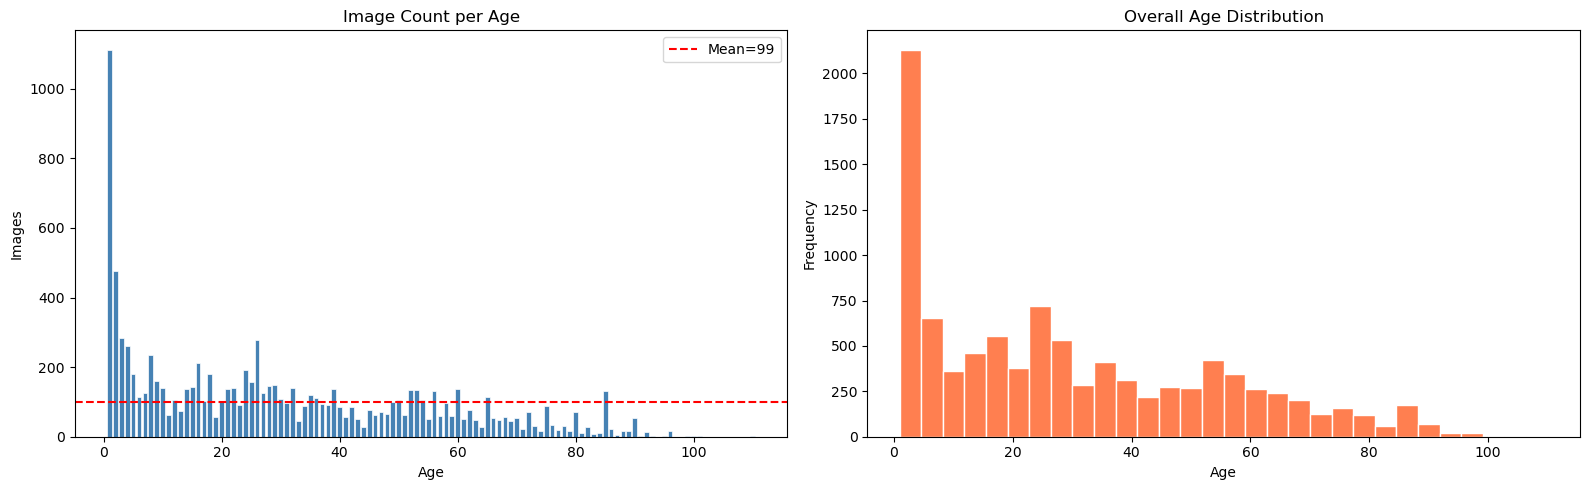

Saved: age_distribution.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].bar(ages, counts, color='steelblue', edgecolor='white', linewidth=0.5)
axes[0].axhline(np.mean(counts), color='red', linestyle='--',
                label=f'Mean={np.mean(counts):.0f}')
axes[0].set_xlabel('Age'); axes[0].set_ylabel('Images')
axes[0].set_title('Image Count per Age'); axes[0].legend()

axes[1].hist(np.repeat(ages, counts), bins=30, color='coral', edgecolor='white')
axes[1].set_xlabel('Age'); axes[1].set_ylabel('Frequency')
axes[1].set_title('Overall Age Distribution')

plt.tight_layout()
plt.savefig('age_distribution.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: age_distribution.png')


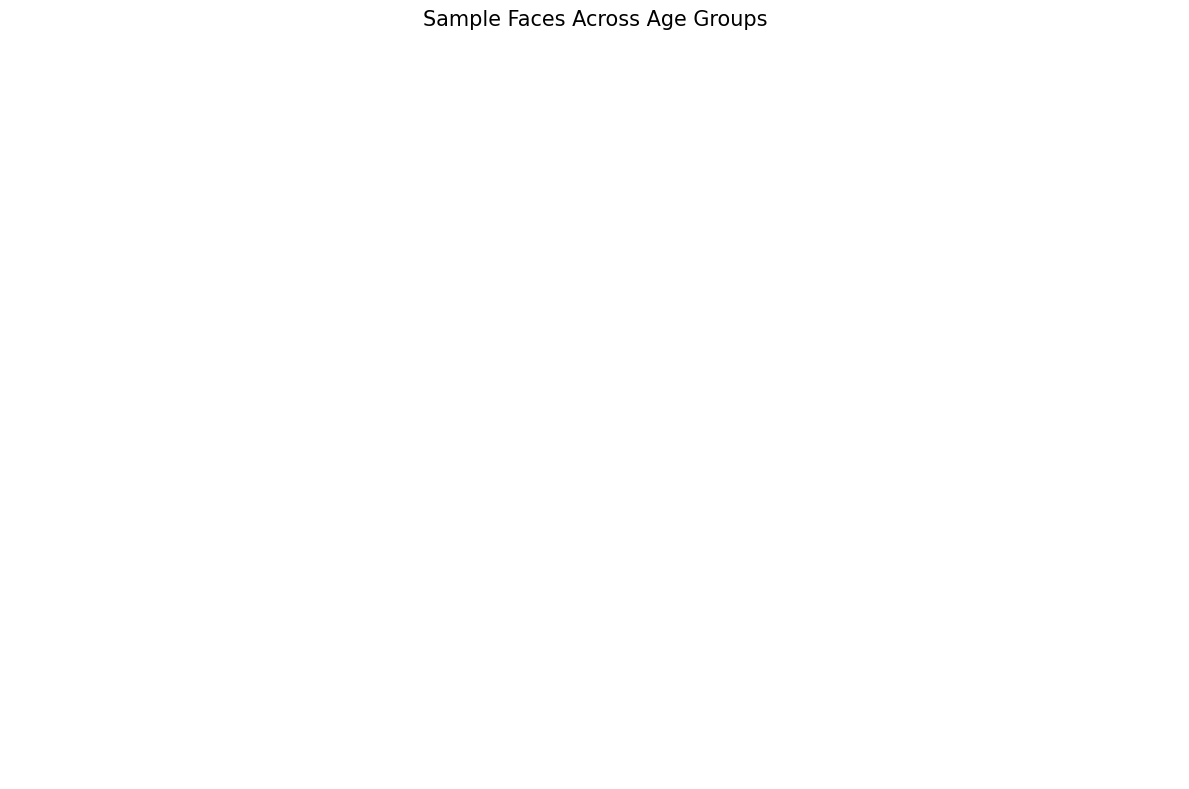

In [6]:
sample_ages = [5, 15, 25, 35, 50, 65]
fig, axes   = plt.subplots(2, 3, figsize=(12, 8))

for ax, age in zip(axes.flat, sample_ages):
    folder = os.path.join(RAW_DIR, str(age))
    if not os.path.isdir(folder):
        ax.axis('off'); continue
    imgs = [f for f in os.listdir(folder)
            if os.path.splitext(f)[1].lower() in valid_ext]
    if not imgs:
        ax.axis('off'); continue
    img = Image.open(os.path.join(folder, random.choice(imgs))).convert('RGB')
    ax.imshow(img)
    ax.set_title(f'Age: {age}', fontsize=13)
    ax.axis('off')

plt.suptitle('Sample Faces Across Age Groups', fontsize=15)
plt.tight_layout()
plt.savefig('sample_faces.png', dpi=120, bbox_inches='tight')
plt.show()


## 3. Dataset Preparation — Splits and CSV Labels

In [7]:
CATEGORIES = [
    ('child',   0,  12),
    ('teen',   13,  19),
    ('youth',  20,  30),
    ('mid',    31,  45),
    ('mature', 46,  60),
    ('older',  61, 120),
]
CAT_NAMES   = [c[0] for c in CATEGORIES]
NUM_CLASSES = len(CATEGORIES)

def age_to_category(age):
    for idx, (name, lo, hi) in enumerate(CATEGORIES):
        if lo <= age <= hi:
            return idx, name
    return len(CATEGORIES) - 1, CATEGORIES[-1][0]

all_records = []
for age_dir in age_dirs:
    age    = int(age_dir)
    folder = os.path.join(RAW_DIR, age_dir)
    imgs   = [f for f in os.listdir(folder)
               if os.path.splitext(f)[1].lower() in valid_ext]
    for img_file in imgs:
        cat_idx, cat_name = age_to_category(age)
        all_records.append({
            'path':          os.path.join(folder, img_file),
            'age':           age,
            'category_idx':  cat_idx,
            'category_name': cat_name
        })

random.shuffle(all_records)
N      = len(all_records)
test_n = int(0.10 * N)
val_n  = int(0.15 * N)

test_records  = all_records[:test_n]
val_records   = all_records[test_n:test_n + val_n]
train_records = all_records[test_n + val_n:]

for split_name, records in [('train', train_records),
                              ('val',   val_records),
                              ('test',  test_records)]:
    pd.DataFrame(records).to_csv(f'data/{split_name}.csv', index=False)

print(f'Total  : {N:,}')
print(f'Train  : {len(train_records):,}')
print(f'Val    : {len(val_records):,}')
print(f'Test   : {len(test_records):,}')


Total  : 9,778
Train  : 7,335
Val    : 1,466
Test   : 977


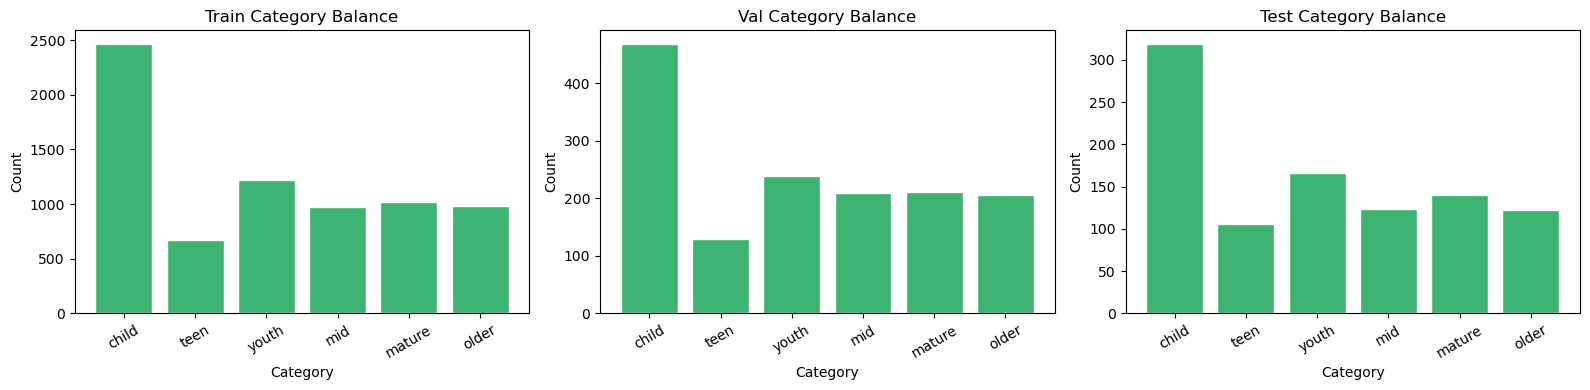

In [8]:
train_df = pd.read_csv('data/train.csv')
val_df   = pd.read_csv('data/val.csv')
test_df  = pd.read_csv('data/test.csv')

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (df, title) in zip(axes, [(train_df,'Train'),
                                    (val_df,  'Val'),
                                    (test_df, 'Test')]):
    cat_counts = df['category_name'].value_counts().reindex(CAT_NAMES, fill_value=0)
    ax.bar(CAT_NAMES, cat_counts.values, color='mediumseagreen', edgecolor='white')
    ax.set_title(f'{title} Category Balance')
    ax.set_xlabel('Category'); ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig('category_balance.png', dpi=120, bbox_inches='tight')
plt.show()


## 4. Dataset Class and Transforms

**`num_workers` note:** On Windows, set `num_workers=0` to avoid multiprocessing issues.  
On Linux/Mac you can use `num_workers=4` or higher for faster data loading.


In [ ]:
IMG_SIZE = 64

import platform
NUM_WORKERS = 0 if platform.system() == 'Windows' else 4
print(f'num_workers set to {NUM_WORKERS}  (0 required on Windows)')


class FaceAgeDataset(Dataset):
    """Loads face images from a CSV. Supports 1-channel (grayscale) or 3-channel (RGB)."""
    def __init__(self, csv_path, transform=None, channels=3):
        self.df        = pd.read_csv(csv_path)
        self.transform = transform
        self.channels  = channels

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row  = self.df.iloc[idx]
        mode = 'L' if self.channels == 1 else 'RGB'
        img  = Image.open(row['path']).convert(mode)
        if self.transform:
            img = self.transform(img)
        age = torch.tensor(row['age'],          dtype=torch.float32)
        cat = torch.tensor(row['category_idx'], dtype=torch.long)
        return img, age, cat


def get_transforms(augment=False, channels=3):
    norm      = transforms.Normalize([0.5]*channels, [0.5]*channels)
    base_list = [
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        norm,
    ]
    aug_list = [
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(10),
        transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
        transforms.ToTensor(),
        norm,
    ]
    if channels == 3:
        aug_list.insert(3, transforms.ColorJitter(brightness=0.2, contrast=0.2))
    train_tf = transforms.Compose(aug_list if augment else base_list)
    eval_tf  = transforms.Compose(base_list)
    return train_tf, eval_tf


def get_loaders(channels=3, augment=False, batch_size=64):
    train_tf, eval_tf = get_transforms(augment=augment, channels=channels)
    # pin_memory=True speeds up CPU→GPU transfer; only effective when using GPU
    kw       = dict(num_workers=NUM_WORKERS, pin_memory=(DEVICE.type == 'cuda'))
    train_ds = FaceAgeDataset('data/train.csv', transform=train_tf, channels=channels)
    val_ds   = FaceAgeDataset('data/val.csv',   transform=eval_tf,  channels=channels)
    test_ds  = FaceAgeDataset('data/test.csv',  transform=eval_tf,  channels=channels)
    return (DataLoader(train_ds, batch_size=batch_size, shuffle=True,  **kw),
            DataLoader(val_ds,   batch_size=batch_size, shuffle=False, **kw),
            DataLoader(test_ds,  batch_size=batch_size, shuffle=False, **kw))

print('Dataset classes defined.')


num_workers set to 0  (0 required on Windows)
Dataset classes defined.


## 5. Training and Evaluation Utilities

In [10]:
def train_one_epoch(model, loader, optimizer, loss_fn, task):
    model.train()
    total, n = 0.0, 0
    for imgs, ages, cats in loader:
        imgs    = imgs.to(DEVICE)
        targets = ages.to(DEVICE) if task == 'regression' else cats.to(DEVICE)
        optimizer.zero_grad()
        out  = model(imgs)
        if task == 'regression':
            out = out.squeeze(1)
        loss = loss_fn(out, targets)
        loss.backward()
        optimizer.step()
        total += loss.item() * len(imgs); n += len(imgs)
    return total / n


@torch.no_grad()
def evaluate(model, loader, loss_fn, task):
    model.eval()
    total, n = 0.0, 0
    all_preds, all_targets = [], []
    for imgs, ages, cats in loader:
        imgs    = imgs.to(DEVICE)
        targets = ages.to(DEVICE) if task == 'regression' else cats.to(DEVICE)
        out     = model(imgs)
        if task == 'regression':
            out = out.squeeze(1)
        total += loss_fn(out, targets).item() * len(imgs); n += len(imgs)
        if task == 'regression':
            all_preds.extend(out.cpu().numpy())
            all_targets.extend(targets.cpu().numpy())
        else:
            all_preds.extend(out.argmax(1).cpu().numpy())
            all_targets.extend(targets.cpu().numpy())
    avg_loss = total / n
    if task == 'regression':
        return avg_loss, mean_absolute_error(all_targets, all_preds)
    else:
        return avg_loss, float(np.mean(np.array(all_preds) == np.array(all_targets)))


def train_model(model, train_loader, val_loader, task='regression',
                epochs=30, lr=1e-3, label='model',
                patience=7, weight_decay=1e-4):
    """Full training loop with early stopping and LR scheduling."""
    model      = model.to(DEVICE)
    loss_fn    = nn.MSELoss() if task == 'regression' else nn.CrossEntropyLoss()
    metric_key = 'val_mae'    if task == 'regression' else 'val_acc'
    optimizer  = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler  = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)

    history          = {'train_loss': [], 'val_loss': [], metric_key: []}
    best_val         = float('inf') if task == 'regression' else 0.0
    best_state       = None
    patience_counter = 0

    for epoch in range(1, epochs + 1):
        t_loss           = train_one_epoch(model, train_loader, optimizer, loss_fn, task)
        v_loss, v_metric = evaluate(model, val_loader, loss_fn, task)
        scheduler.step(v_loss)

        history['train_loss'].append(t_loss)
        history['val_loss'].append(v_loss)
        history[metric_key].append(v_metric)

        improved = (v_metric < best_val) if task == 'regression' else (v_metric > best_val)
        if improved:
            best_val         = v_metric
            best_state       = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1

        if epoch % 5 == 0 or epoch == 1:
            mname = 'MAE' if task == 'regression' else 'Acc'
            print(f'  Ep {epoch:3d}/{epochs}  '
                  f'TrainLoss {t_loss:.4f}  ValLoss {v_loss:.4f}  '
                  f'Val{mname} {v_metric:.4f}')

        if patience_counter >= patience:
            print(f'  Early stopping at epoch {epoch}')
            break

    if best_state:
        model.load_state_dict(best_state)
    return history, best_val


def plot_history(history, label, task):
    metric_key   = 'val_mae' if task == 'regression' else 'val_acc'
    metric_label = 'Val MAE (years)' if task == 'regression' else 'Val Accuracy'
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
    ax1.plot(history['train_loss'], label='Train Loss', color='royalblue')
    ax1.plot(history['val_loss'],   label='Val Loss',   color='coral')
    ax1.set_title(f'{label} -- Loss'); ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss'); ax1.legend()
    ax2.plot(history[metric_key], color='mediumseagreen', label=metric_label)
    ax2.set_title(f'{label} -- {metric_label}')
    ax2.set_xlabel('Epoch'); ax2.set_ylabel(metric_label); ax2.legend()
    plt.tight_layout()
    safe = label.replace(' ', '_').replace('/', '_')
    plt.savefig(f'history_{safe}.png', dpi=100, bbox_inches='tight')
    plt.show()

print('Training utilities defined.')


Training utilities defined.


## 6. Model Architectures

In [ ]:

# FlexCNN: configurable kernel, activation, depth, pooling, FC
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, kernel=3, activation=nn.ReLU, use_pool=True):
        super().__init__()
        pad    = kernel // 2
        layers = [nn.Conv2d(in_ch, out_ch, kernel, padding=pad),
                  nn.BatchNorm2d(out_ch), activation()]
        if use_pool:
            layers.append(nn.MaxPool2d(2))
        self.block = nn.Sequential(*layers)

    def forward(self, x): return self.block(x)


class FlexCNN(nn.Module):
    def __init__(self, depth=3, kernel=3, activation=nn.ReLU,
                 use_pool=True, fc_layers=None, task='regression', channels=3):
        super().__init__()
        if fc_layers is None:
            fc_layers = [256, 128]
        self.task  = task
        ch_seq     = [channels] + [min(32 * 2**i, 256) for i in range(depth)]
        self.features = nn.Sequential(*[
            ConvBlock(ch_seq[i], ch_seq[i+1], kernel, activation, use_pool)
            for i in range(depth)
        ])
        with torch.no_grad():
            feat_size = self.features(
                torch.zeros(1, channels, IMG_SIZE, IMG_SIZE)).numel()
        fc_in, parts = feat_size, []
        for fc_out in fc_layers:
            parts += [nn.Linear(fc_in, fc_out), activation(), nn.Dropout(0.4)]
            fc_in  = fc_out
        parts.append(nn.Linear(fc_in, 1 if task == 'regression' else NUM_CLASSES))
        self.classifier = nn.Sequential(*parts)

    def forward(self, x):
        return self.classifier(self.features(x).flatten(1))


# ResCNN: residual (skip-connection) blocks
class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, activation=nn.ReLU):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch,  out_ch, 3, padding=1)
        self.bn1   = nn.BatchNorm2d(out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.bn2   = nn.BatchNorm2d(out_ch)
        self.act   = activation()
        self.proj  = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()
        self.pool  = nn.MaxPool2d(2)

    def forward(self, x):
        res = self.proj(x)
        out = self.act(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        return self.pool(self.act(out + res))


class ResCNN(nn.Module):
    def __init__(self, depth=3, activation=nn.ReLU,
                 fc_layers=None, task='regression', channels=3):
        super().__init__()
        if fc_layers is None:
            fc_layers = [256, 128]
        self.task  = task
        ch_seq     = [channels] + [min(32 * 2**i, 256) for i in range(depth)]
        self.features = nn.Sequential(*[
            ResBlock(ch_seq[i], ch_seq[i+1], activation) for i in range(depth)
        ])
        with torch.no_grad():
            feat_size = self.features(
                torch.zeros(1, channels, IMG_SIZE, IMG_SIZE)).numel()
        fc_in, parts = feat_size, []
        for fc_out in fc_layers:
            parts += [nn.Linear(fc_in, fc_out), activation(), nn.Dropout(0.4)]
            fc_in  = fc_out
        parts.append(nn.Linear(fc_in, 1 if task == 'regression' else NUM_CLASSES))
        self.classifier = nn.Sequential(*parts)

    def forward(self, x):
        return self.classifier(self.features(x).flatten(1))


# MultiScaleCNN: 3×3 + 5×5 + 7×7 parallel branches per block
class MultiScaleBlock(nn.Module):
    def __init__(self, in_ch, out_ch, activation=nn.ReLU):
        super().__init__()
        bch = max(out_ch // 3, 8)
        self.b3    = nn.Sequential(nn.Conv2d(in_ch, bch, 3, padding=1), nn.BatchNorm2d(bch), activation())
        self.b5    = nn.Sequential(nn.Conv2d(in_ch, bch, 5, padding=2), nn.BatchNorm2d(bch), activation())
        self.b7    = nn.Sequential(nn.Conv2d(in_ch, bch, 7, padding=3), nn.BatchNorm2d(bch), activation())
        self.merge = nn.Conv2d(bch * 3, out_ch, 1)
        self.pool  = nn.MaxPool2d(2)

    def forward(self, x):
        x = torch.cat([self.b3(x), self.b5(x), self.b7(x)], dim=1)
        return self.pool(self.merge(x))


class MultiScaleCNN(nn.Module):
    def __init__(self, depth=3, activation=nn.ReLU,
                 fc_layers=None, task='regression', channels=3):
        super().__init__()
        if fc_layers is None:
            fc_layers = [256, 128]
        self.task  = task
        ch_seq     = [channels] + [min(32 * 2**i, 128) for i in range(depth)]
        self.features = nn.Sequential(*[
            MultiScaleBlock(ch_seq[i], ch_seq[i+1], activation) for i in range(depth)
        ])
        with torch.no_grad():
            feat_size = self.features(
                torch.zeros(1, channels, IMG_SIZE, IMG_SIZE)).numel()
        fc_in, parts = feat_size, []
        for fc_out in fc_layers:
            parts += [nn.Linear(fc_in, fc_out), activation(), nn.Dropout(0.4)]
            fc_in  = fc_out
        parts.append(nn.Linear(fc_in, 1 if task == 'regression' else NUM_CLASSES))
        self.classifier = nn.Sequential(*parts)

    def forward(self, x):
        return self.classifier(self.features(x).flatten(1))


class FlexCNN_Softmax(FlexCNN):
    """FlexCNN with explicit softmax — suboptimal with CrossEntropyLoss."""
    def forward(self, x):
        return F.softmax(super().forward(x), dim=-1)


MODEL_REGISTRY = {
    'FlexCNN':         FlexCNN,
    'ResCNN':          ResCNN,
    'MultiScaleCNN':   MultiScaleCNN,
    'FlexCNN_Softmax': FlexCNN_Softmax,
}

def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

for name, m in [('FlexCNN reg',    FlexCNN()),
                ('FlexCNN cls',    FlexCNN(task='classification')),
                ('ResCNN reg',     ResCNN()),
                ('MultiScale cls', MultiScaleCNN(task='classification'))]:
    print(f'  {name:22s}  params: {count_params(m):,}')


  FlexCNN reg             params: 2,224,129
  FlexCNN cls             params: 2,224,774
  ResCNN reg              params: 2,428,897
  MultiScale cls          params: 2,434,449


## 7. Experiment Runner

In [12]:
RESULTS = []   # accumulates all experiment results

def run_experiment(name, model_fn, task='regression', channels=3,
                   augment=False, epochs=30, lr=1e-3, batch_size=64):
    print(f'\n{"="*60}')
    print(f'  {name}  [{task}]')
    print(f'{"="*60}')

    train_loader, val_loader, test_loader = get_loaders(
        channels=channels, augment=augment, batch_size=batch_size)

    model = model_fn()
    print(f'  Params: {count_params(model):,}')

    history, best_val = train_model(
        model, train_loader, val_loader,
        task=task, epochs=epochs, lr=lr, label=name)

    loss_fn                = nn.MSELoss() if task == 'regression' else nn.CrossEntropyLoss()
    test_loss, test_metric = evaluate(model, test_loader, loss_fn, task)
    mname                  = 'MAE' if task == 'regression' else 'Acc'
    print(f'  Test {mname}: {test_metric:.4f}')

    plot_history(history, label=name, task=task)

    RESULTS.append(dict(name=name, task=task, channels=channels,
                        augment=augment, best_val=best_val,
                        test_metric=test_metric, metric_name=mname,
                        history=history, model=model))
    return model, history, test_metric

print('run_experiment() ready.')


run_experiment() ready.


## 8. CNN Kernel Variations
### 8.1 Activation Functions


  Activation-ReLU  [regression]
  Params: 2,224,129
  Ep   1/30  TrainLoss 467.1721  ValLoss 397.9561  ValMAE 16.2866
  Ep   5/30  TrainLoss 132.6750  ValLoss 163.5800  ValMAE 8.7695
  Ep  10/30  TrainLoss 98.7334  ValLoss 126.6005  ValMAE 7.6721
  Ep  15/30  TrainLoss 64.9249  ValLoss 101.9429  ValMAE 6.7904
  Ep  20/30  TrainLoss 49.2519  ValLoss 95.4388  ValMAE 6.5746
  Ep  25/30  TrainLoss 41.3128  ValLoss 100.2062  ValMAE 6.6582
  Ep  30/30  TrainLoss 39.4520  ValLoss 98.1690  ValMAE 6.5738
  Test MAE: 5.9666


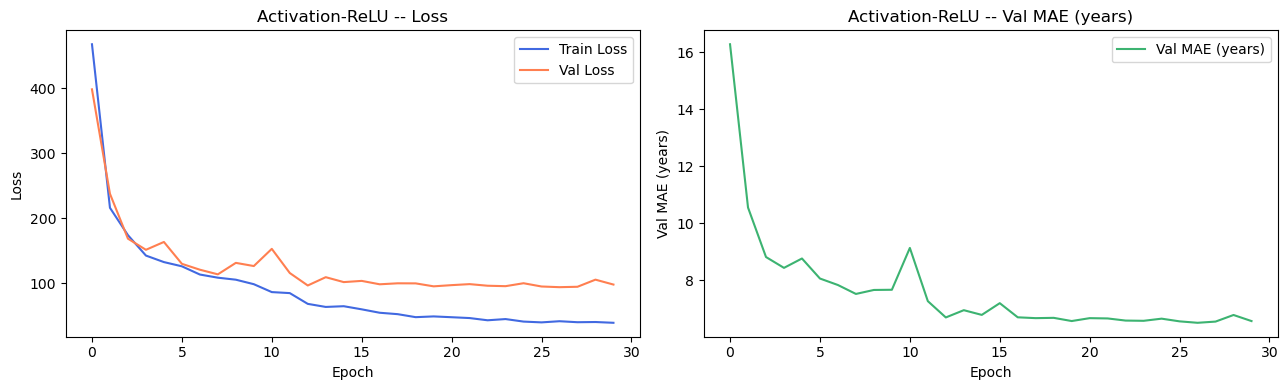


  Activation-ELU  [regression]
  Params: 2,224,129
  Ep   1/30  TrainLoss 396.3739  ValLoss 236.1855  ValMAE 10.9577
  Ep   5/30  TrainLoss 121.3118  ValLoss 126.7424  ValMAE 7.9429
  Ep  10/30  TrainLoss 76.8970  ValLoss 96.6403  ValMAE 6.7376
  Ep  15/30  TrainLoss 62.7773  ValLoss 106.1044  ValMAE 7.0379
  Ep  20/30  TrainLoss 38.6441  ValLoss 83.8552  ValMAE 6.4594
  Ep  25/30  TrainLoss 31.7155  ValLoss 85.7001  ValMAE 6.3372
  Ep  30/30  TrainLoss 26.2690  ValLoss 85.5329  ValMAE 6.3975
  Test MAE: 6.0171


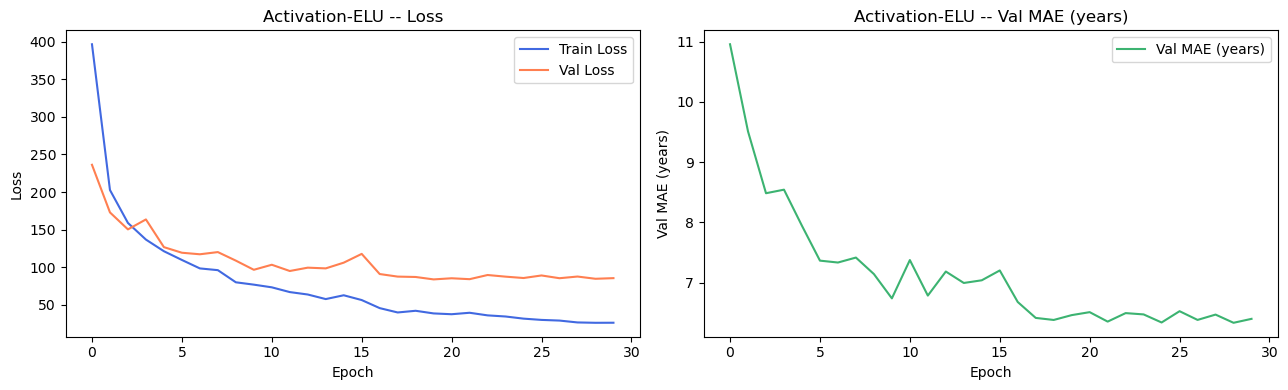


  Activation-LeakyReLU  [regression]
  Params: 2,224,129
  Ep   1/30  TrainLoss 451.0880  ValLoss 254.1789  ValMAE 11.1128
  Ep   5/30  TrainLoss 125.4592  ValLoss 132.1289  ValMAE 7.8210
  Ep  10/30  TrainLoss 82.4509  ValLoss 102.0496  ValMAE 6.8590
  Ep  15/30  TrainLoss 74.7399  ValLoss 104.0544  ValMAE 7.0062
  Ep  20/30  TrainLoss 45.3193  ValLoss 89.1907  ValMAE 6.4529
  Ep  25/30  TrainLoss 42.8277  ValLoss 88.8508  ValMAE 6.6128
  Ep  30/30  TrainLoss 31.8695  ValLoss 86.4087  ValMAE 6.1552
  Test MAE: 5.7061


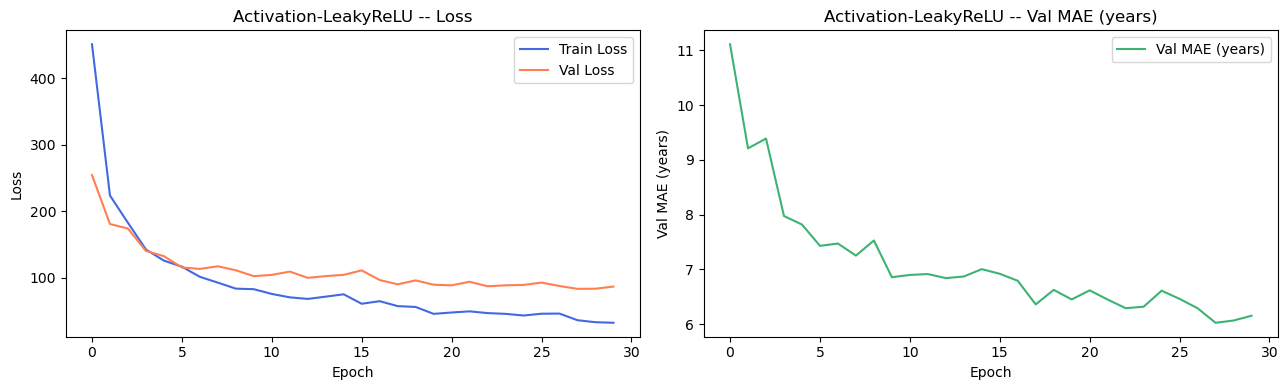


  Activation-SELU  [regression]
  Params: 2,224,129
  Ep   1/30  TrainLoss 391.0402  ValLoss 218.4296  ValMAE 10.6987
  Ep   5/30  TrainLoss 125.9098  ValLoss 198.3135  ValMAE 9.1318
  Ep  10/30  TrainLoss 76.3320  ValLoss 106.1548  ValMAE 7.1754
  Ep  15/30  TrainLoss 56.4659  ValLoss 105.1552  ValMAE 6.8538
  Ep  20/30  TrainLoss 43.4617  ValLoss 94.8017  ValMAE 6.6707
  Ep  25/30  TrainLoss 33.1209  ValLoss 89.2545  ValMAE 6.3712
  Ep  30/30  TrainLoss 30.1378  ValLoss 94.7006  ValMAE 6.7719
  Test MAE: 5.8156


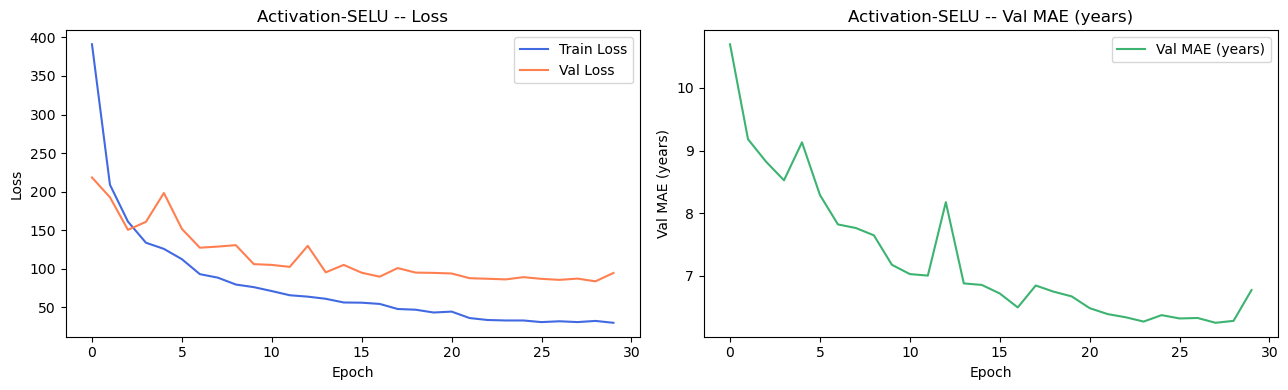

In [13]:
ACTIVATIONS = {
    'ReLU':      nn.ReLU,
    'ELU':       nn.ELU,
    'LeakyReLU': nn.LeakyReLU,
    'SELU':      nn.SELU,
}
for act_name, act_cls in ACTIVATIONS.items():
    run_experiment(
        name=f'Activation-{act_name}',
        model_fn=lambda a=act_cls: FlexCNN(activation=a, task='regression'),
        task='regression', epochs=30
    )


### 8.2 Kernel Sizes


  Kernel-3x3  [regression]
  Params: 2,224,129
  Ep   1/30  TrainLoss 435.7599  ValLoss 215.6486  ValMAE 10.5475
  Ep   5/30  TrainLoss 138.8762  ValLoss 180.8407  ValMAE 9.1455
  Ep  10/30  TrainLoss 93.1666  ValLoss 125.0174  ValMAE 7.5490
  Ep  15/30  TrainLoss 70.3479  ValLoss 107.6604  ValMAE 7.1562
  Ep  20/30  TrainLoss 52.9158  ValLoss 96.1047  ValMAE 6.7387
  Early stopping at epoch 24
  Test MAE: 5.9043


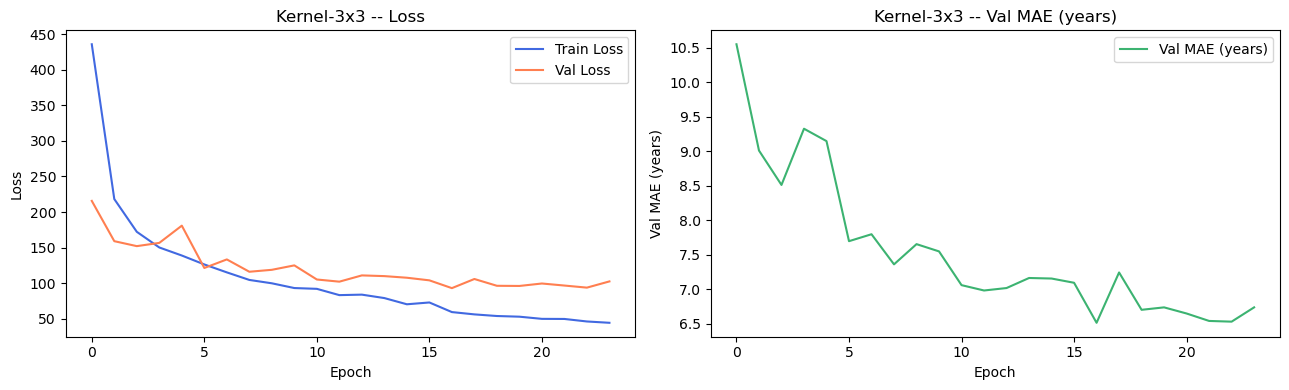


  Kernel-5x5  [regression]
  Params: 2,389,505
  Ep   1/30  TrainLoss 430.0284  ValLoss 388.4367  ValMAE 13.6037
  Ep   5/30  TrainLoss 147.0399  ValLoss 132.3653  ValMAE 8.1503
  Ep  10/30  TrainLoss 103.9243  ValLoss 114.4362  ValMAE 7.2278
  Ep  15/30  TrainLoss 79.0542  ValLoss 106.1983  ValMAE 7.0000
  Ep  20/30  TrainLoss 63.6549  ValLoss 111.2710  ValMAE 7.3646
  Ep  25/30  TrainLoss 46.6094  ValLoss 96.1721  ValMAE 6.5513
  Ep  30/30  TrainLoss 35.8285  ValLoss 90.8774  ValMAE 6.3383
  Test MAE: 5.8894


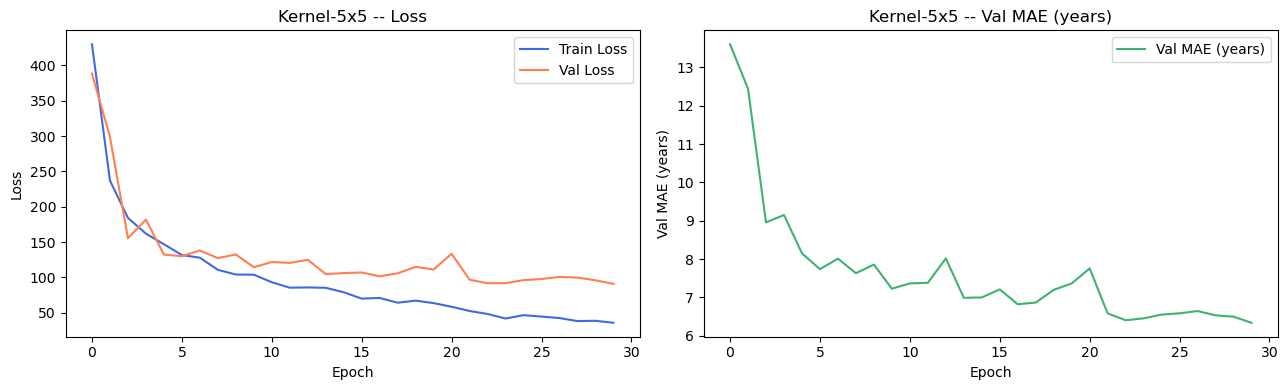


  Kernel-7x7  [regression]
  Params: 2,637,569
  Ep   1/30  TrainLoss 435.4144  ValLoss 547.4831  ValMAE 20.2093
  Ep   5/30  TrainLoss 153.7348  ValLoss 157.3313  ValMAE 8.4058
  Ep  10/30  TrainLoss 97.4847  ValLoss 116.4041  ValMAE 7.3830
  Ep  15/30  TrainLoss 72.6797  ValLoss 108.8509  ValMAE 6.9387
  Ep  20/30  TrainLoss 63.3313  ValLoss 104.1024  ValMAE 6.7538
  Ep  25/30  TrainLoss 44.7460  ValLoss 94.2267  ValMAE 6.5217
  Ep  30/30  TrainLoss 42.5166  ValLoss 110.1091  ValMAE 6.8874
  Test MAE: 5.8183


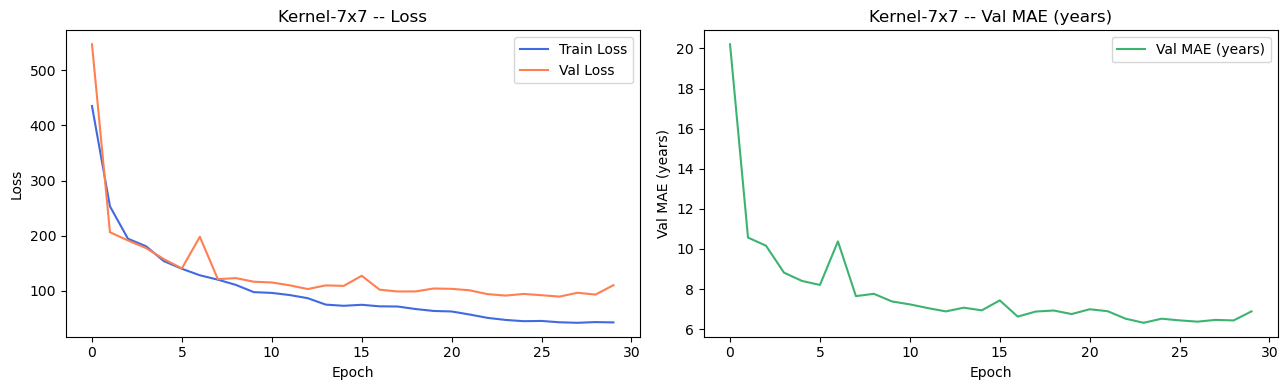

In [14]:
for ks in [3, 5, 7]:
    run_experiment(
        name=f'Kernel-{ks}x{ks}',
        model_fn=lambda k=ks: FlexCNN(kernel=k, task='regression'),
        task='regression', epochs=30
    )


## 9. Network Architecture Variations
### 9.1 Network Depth


  Depth-2  [regression]
  Params: 4,247,169
  Ep   1/30  TrainLoss 370.5221  ValLoss 211.7443  ValMAE 10.3710
  Ep   5/30  TrainLoss 141.6305  ValLoss 165.8138  ValMAE 8.7013
  Ep  10/30  TrainLoss 105.4654  ValLoss 120.9967  ValMAE 7.4770
  Ep  15/30  TrainLoss 76.9146  ValLoss 160.6991  ValMAE 8.6682
  Ep  20/30  TrainLoss 65.0780  ValLoss 113.0948  ValMAE 7.0113
  Early stopping at epoch 23
  Test MAE: 6.5028


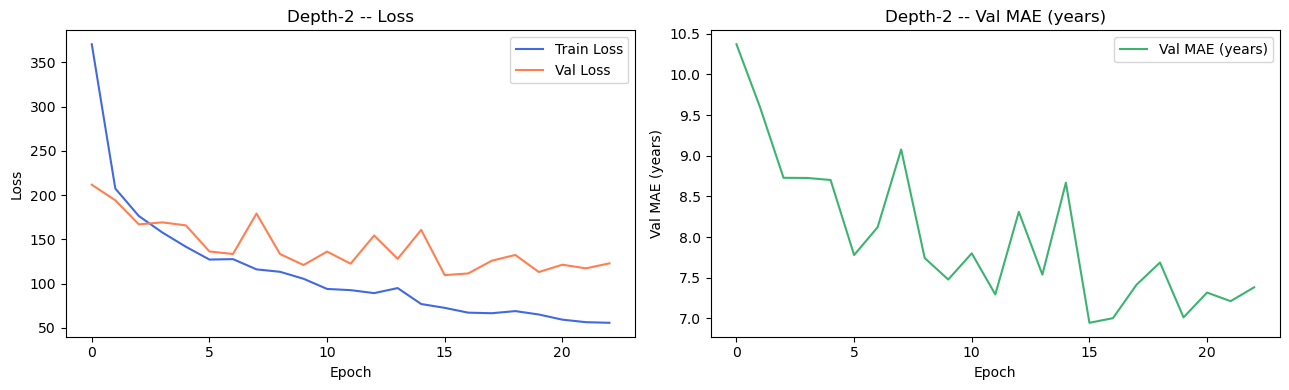


  Depth-3  [regression]
  Params: 2,224,129
  Ep   1/30  TrainLoss 404.6655  ValLoss 306.6786  ValMAE 12.0673
  Ep   5/30  TrainLoss 135.5129  ValLoss 126.6494  ValMAE 7.7220
  Ep  10/30  TrainLoss 99.7406  ValLoss 136.8347  ValMAE 7.8803
  Ep  15/30  TrainLoss 74.8235  ValLoss 109.6924  ValMAE 7.0054
  Ep  20/30  TrainLoss 64.6043  ValLoss 112.9462  ValMAE 7.2110
  Ep  25/30  TrainLoss 55.6418  ValLoss 123.5606  ValMAE 7.4424
  Early stopping at epoch 28
  Test MAE: 6.1048


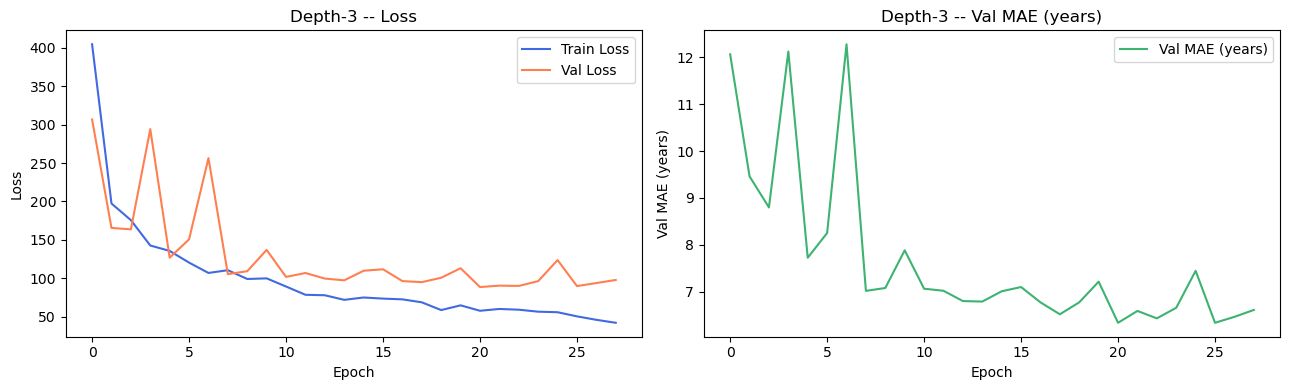


  Depth-4  [regression]
  Params: 1,471,233
  Ep   1/30  TrainLoss 405.8787  ValLoss 194.5743  ValMAE 9.7630
  Ep   5/30  TrainLoss 127.3752  ValLoss 118.2630  ValMAE 7.5075
  Ep  10/30  TrainLoss 77.2453  ValLoss 98.5663  ValMAE 6.7579
  Ep  15/30  TrainLoss 65.2408  ValLoss 140.8623  ValMAE 7.9969
  Ep  20/30  TrainLoss 42.3489  ValLoss 92.6760  ValMAE 6.4592
  Ep  25/30  TrainLoss 35.4388  ValLoss 89.2123  ValMAE 6.2680
  Ep  30/30  TrainLoss 33.1185  ValLoss 91.7327  ValMAE 6.3241
  Test MAE: 5.8548


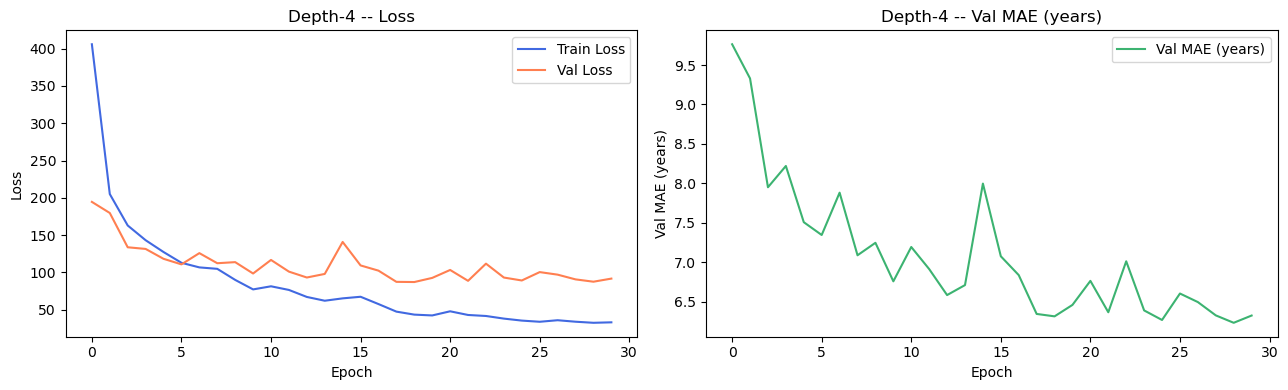


  Depth-5  [regression]
  Params: 1,275,393
  Ep   1/30  TrainLoss 359.1487  ValLoss 224.3596  ValMAE 10.2469
  Ep   5/30  TrainLoss 122.1425  ValLoss 136.3106  ValMAE 8.2209
  Ep  10/30  TrainLoss 68.0610  ValLoss 105.1591  ValMAE 7.0276
  Ep  15/30  TrainLoss 53.2504  ValLoss 99.3765  ValMAE 6.6966
  Ep  20/30  TrainLoss 40.3403  ValLoss 87.8161  ValMAE 6.4065
  Ep  25/30  TrainLoss 34.5505  ValLoss 89.5355  ValMAE 6.3059
  Ep  30/30  TrainLoss 32.6146  ValLoss 83.8165  ValMAE 6.1217
  Test MAE: 5.4849


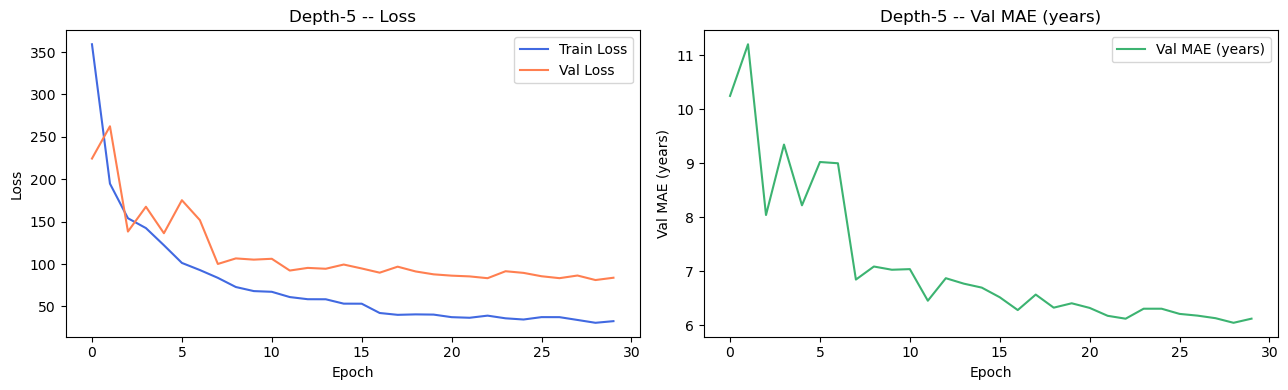

In [15]:
for depth in [2, 3, 4, 5]:
    run_experiment(
        name=f'Depth-{depth}',
        model_fn=lambda d=depth: FlexCNN(depth=d, task='regression'),
        task='regression', epochs=30
    )


### 9.2 With vs Without Pooling


  Pooling-Yes  [regression]
  Params: 2,224,129
  Ep   1/30  TrainLoss 395.7290  ValLoss 214.4055  ValMAE 11.6045
  Ep   5/30  TrainLoss 131.1103  ValLoss 172.1053  ValMAE 8.8646
  Ep  10/30  TrainLoss 86.2462  ValLoss 122.2359  ValMAE 7.9769
  Ep  15/30  TrainLoss 72.9569  ValLoss 119.2592  ValMAE 7.2395
  Ep  20/30  TrainLoss 49.8024  ValLoss 97.3626  ValMAE 6.5216
  Ep  25/30  TrainLoss 50.5512  ValLoss 106.5325  ValMAE 6.8152
  Ep  30/30  TrainLoss 38.4614  ValLoss 100.5058  ValMAE 6.6290
  Early stopping at epoch 30
  Test MAE: 6.0895


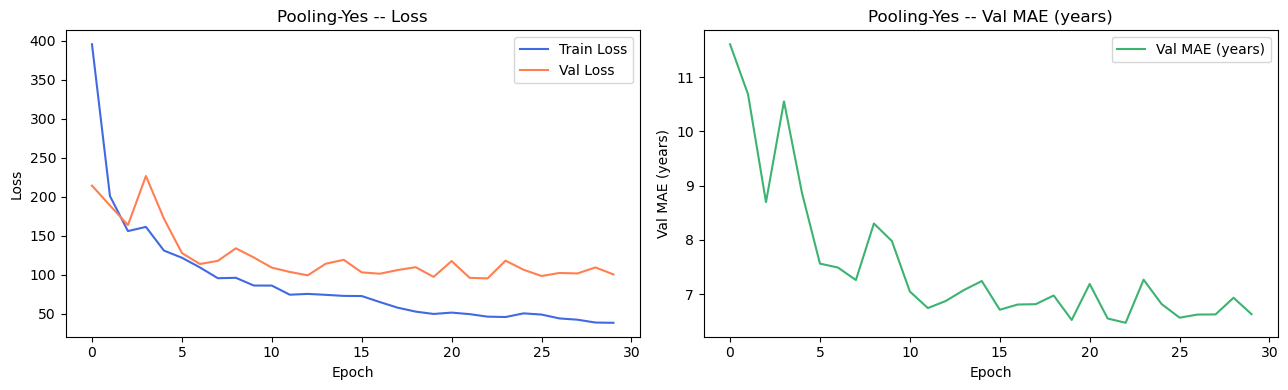


  Pooling-No  [regression]
  Params: 134,344,705
  Ep   1/30  TrainLoss 915.8208  ValLoss 324.6771  ValMAE 12.9804
  Ep   5/30  TrainLoss 182.6037  ValLoss 340.0672  ValMAE 12.9006
  Ep  10/30  TrainLoss 106.6539  ValLoss 315.4664  ValMAE 12.6467
  Early stopping at epoch 14
  Test MAE: 10.3853


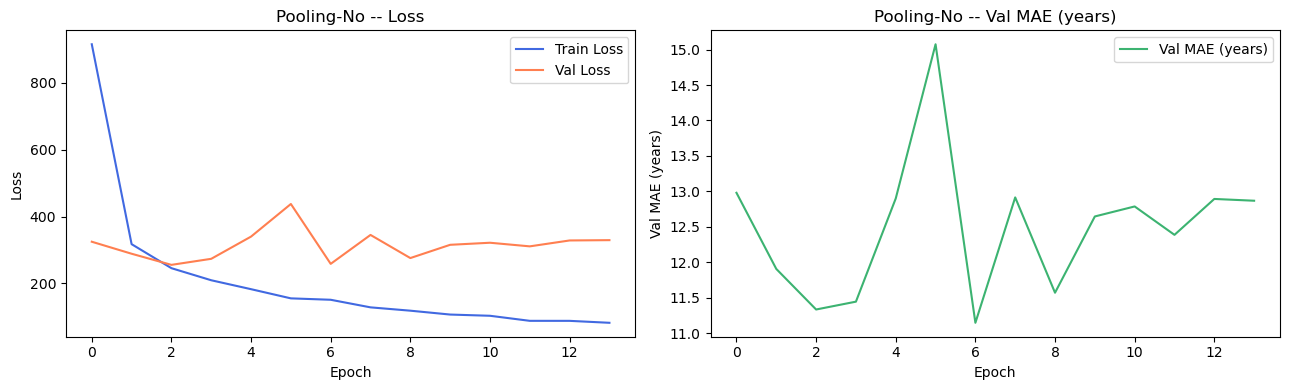

In [16]:
for pool in [True, False]:
    run_experiment(
        name=f'Pooling-{"Yes" if pool else "No"}',
        model_fn=lambda p=pool: FlexCNN(use_pool=p, task='regression'),
        task='regression', epochs=30
    )


### 9.3 Skip Connections


  NoSkip-FlexCNN  [regression]
  Params: 2,224,129
  Ep   1/30  TrainLoss 407.2641  ValLoss 530.1277  ValMAE 19.3472
  Ep   5/30  TrainLoss 135.3602  ValLoss 157.6559  ValMAE 8.4225
  Ep  10/30  TrainLoss 99.6766  ValLoss 117.6680  ValMAE 7.6616
  Ep  15/30  TrainLoss 68.7655  ValLoss 133.9249  ValMAE 7.8670
  Ep  20/30  TrainLoss 63.7441  ValLoss 105.4977  ValMAE 7.1371
  Early stopping at epoch 23
  Test MAE: 5.9601


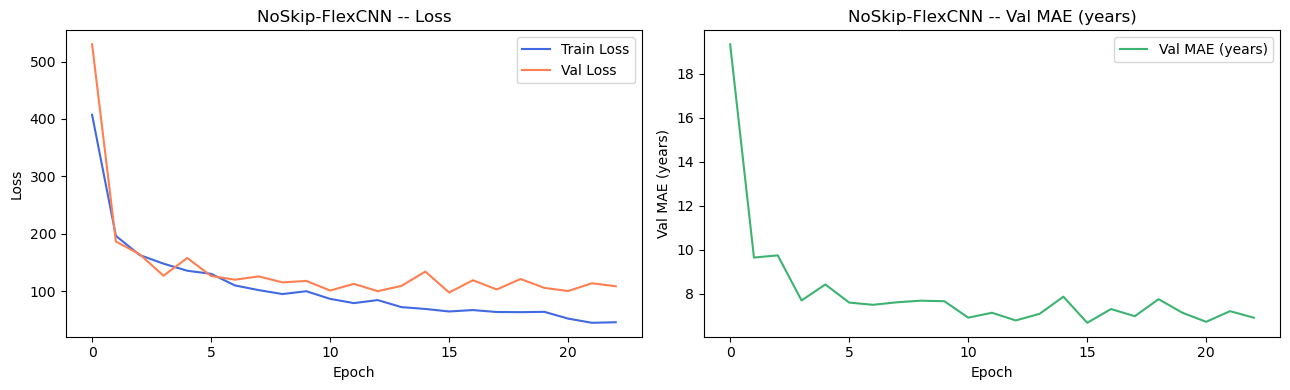


  WithSkip-ResCNN  [regression]
  Params: 2,428,897
  Ep   1/30  TrainLoss 402.6566  ValLoss 250.3379  ValMAE 11.2282
  Ep   5/30  TrainLoss 122.2195  ValLoss 114.2290  ValMAE 7.5060
  Ep  10/30  TrainLoss 75.4787  ValLoss 94.3131  ValMAE 6.4489
  Ep  15/30  TrainLoss 50.9528  ValLoss 88.6972  ValMAE 6.2916
  Ep  20/30  TrainLoss 42.4836  ValLoss 88.0046  ValMAE 6.1042
  Ep  25/30  TrainLoss 36.9048  ValLoss 86.6814  ValMAE 6.0535
  Early stopping at epoch 25
  Test MAE: 5.9648


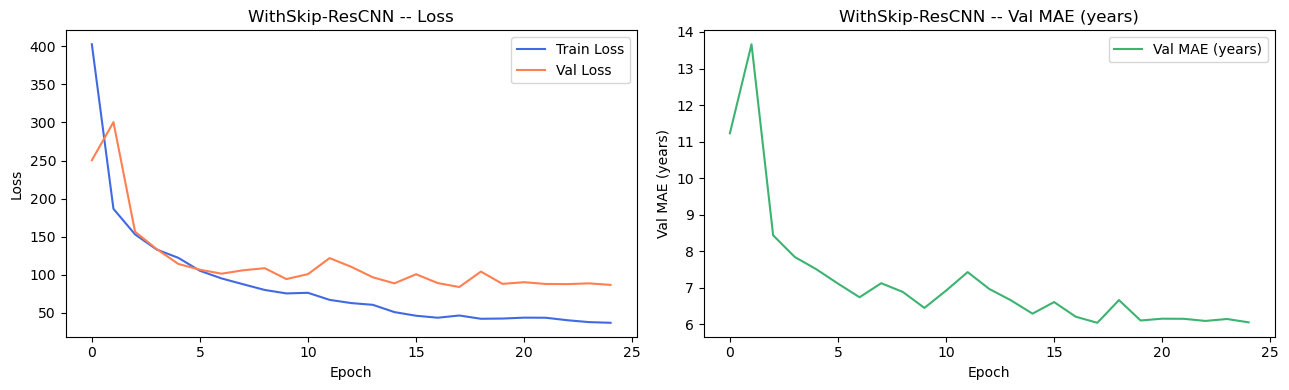

(ResCNN(
   (features): Sequential(
     (0): ResBlock(
       (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
       (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
       (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
       (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
       (act): ReLU()
       (proj): Conv2d(3, 32, kernel_size=(1, 1), stride=(1, 1))
       (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
     )
     (1): ResBlock(
       (conv1): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
       (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
       (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
       (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
       (act): ReLU()
       (proj): Con

In [17]:
run_experiment('NoSkip-FlexCNN',  lambda: FlexCNN(depth=3, task='regression'), task='regression', epochs=30)
run_experiment('WithSkip-ResCNN', lambda: ResCNN(depth=3,  task='regression'), task='regression', epochs=30)


### 9.4 FC Layer Depth Variations


  FC-1FC-128  [regression]
  Params: 1,142,529
  Ep   1/30  TrainLoss 397.7653  ValLoss 211.0636  ValMAE 10.8987
  Ep   5/30  TrainLoss 116.9631  ValLoss 146.6575  ValMAE 8.4329
  Ep  10/30  TrainLoss 76.0533  ValLoss 105.8849  ValMAE 7.0041
  Ep  15/30  TrainLoss 64.3059  ValLoss 174.0945  ValMAE 9.0028
  Ep  20/30  TrainLoss 39.4780  ValLoss 100.8158  ValMAE 6.7904
  Ep  25/30  TrainLoss 36.6617  ValLoss 105.5218  ValMAE 6.7828
  Ep  30/30  TrainLoss 31.3516  ValLoss 97.2859  ValMAE 6.5420
  Test MAE: 6.0205


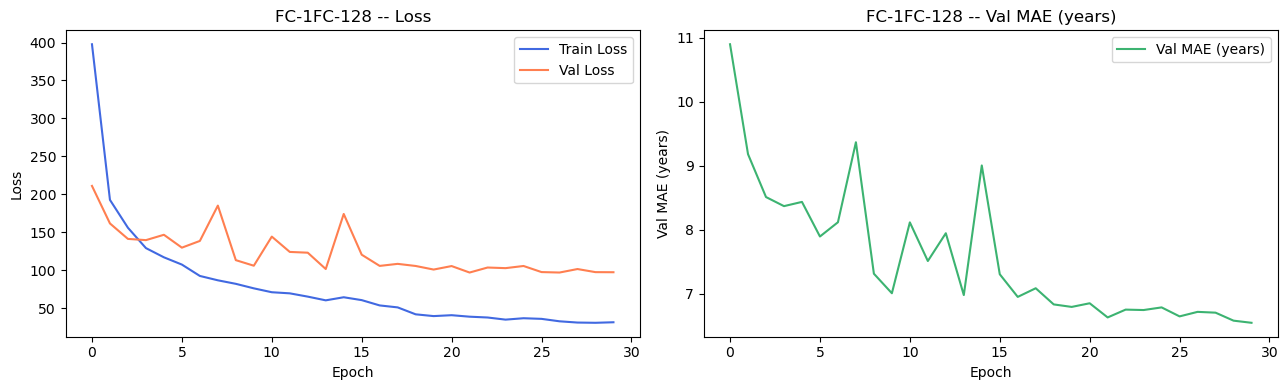


  FC-2FC-256-128  [regression]
  Params: 2,224,129
  Ep   1/30  TrainLoss 398.5126  ValLoss 337.9322  ValMAE 12.7368
  Ep   5/30  TrainLoss 130.6617  ValLoss 149.8213  ValMAE 8.4834
  Ep  10/30  TrainLoss 96.6371  ValLoss 113.1991  ValMAE 7.3030
  Ep  15/30  TrainLoss 60.9312  ValLoss 97.7153  ValMAE 6.5763
  Ep  20/30  TrainLoss 47.9820  ValLoss 94.7345  ValMAE 6.4623
  Ep  25/30  TrainLoss 41.5237  ValLoss 95.0849  ValMAE 6.4315
  Ep  30/30  TrainLoss 37.9579  ValLoss 95.3762  ValMAE 6.3704
  Test MAE: 5.8015


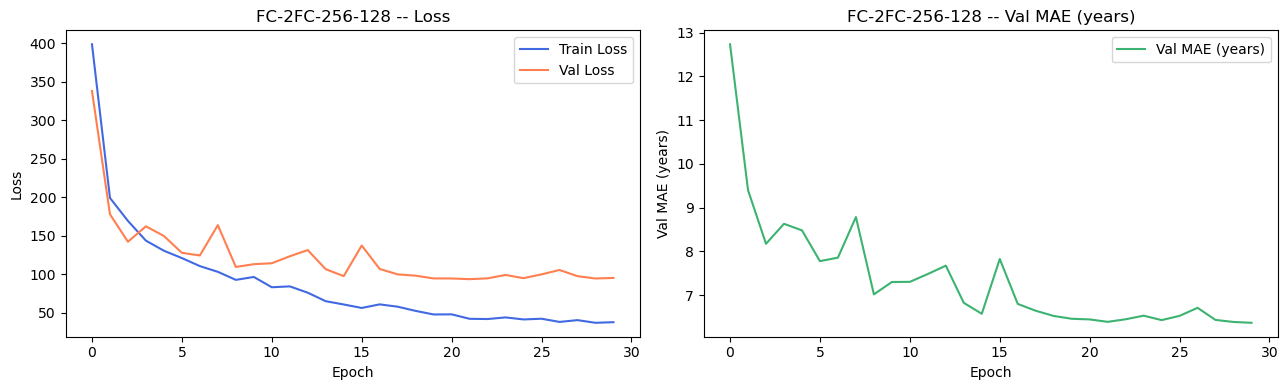


  FC-3FC-512-256-128  [regression]
  Params: 4,452,865
  Ep   1/30  TrainLoss 456.4136  ValLoss 434.2482  ValMAE 17.4163
  Ep   5/30  TrainLoss 139.4665  ValLoss 126.7500  ValMAE 7.8445
  Ep  10/30  TrainLoss 112.8428  ValLoss 119.6667  ValMAE 7.2945
  Ep  15/30  TrainLoss 69.2932  ValLoss 103.5066  ValMAE 6.7943
  Ep  20/30  TrainLoss 64.5838  ValLoss 135.1246  ValMAE 7.7335
  Ep  25/30  TrainLoss 49.0969  ValLoss 95.0591  ValMAE 6.4178
  Ep  30/30  TrainLoss 42.2561  ValLoss 114.2744  ValMAE 7.0713
  Test MAE: 5.9744


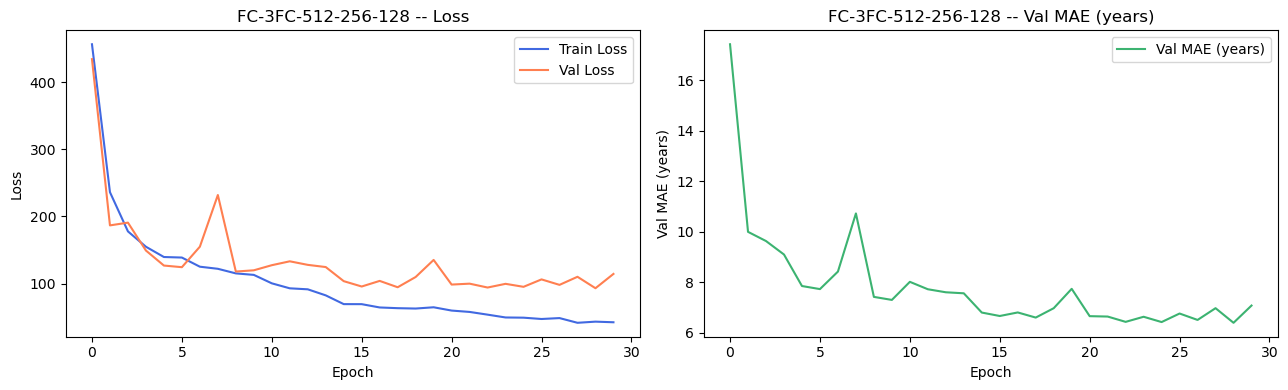

In [18]:
fc_configs = {
    '1FC-128':         [128],
    '2FC-256-128':     [256, 128],
    '3FC-512-256-128': [512, 256, 128],
}
for fc_name, fc_layers in fc_configs.items():
    run_experiment(
        name=f'FC-{fc_name}',
        model_fn=lambda fl=fc_layers: FlexCNN(fc_layers=fl, task='regression'),
        task='regression', epochs=30
    )


## 10. Dataset Variations
### 10.1 Grayscale vs RGB


  Channels-1ch  [regression]
  Params: 2,223,553
  Ep   1/30  TrainLoss 388.8762  ValLoss 197.0434  ValMAE 10.5884
  Ep   5/30  TrainLoss 134.9806  ValLoss 126.4080  ValMAE 7.9893
  Ep  10/30  TrainLoss 96.3106  ValLoss 118.1741  ValMAE 7.3320
  Ep  15/30  TrainLoss 71.3458  ValLoss 115.6444  ValMAE 7.1998
  Ep  20/30  TrainLoss 54.0168  ValLoss 104.6145  ValMAE 6.8011
  Ep  25/30  TrainLoss 40.6118  ValLoss 96.3298  ValMAE 6.5426
  Ep  30/30  TrainLoss 36.7191  ValLoss 98.7632  ValMAE 6.5962
  Test MAE: 6.0625


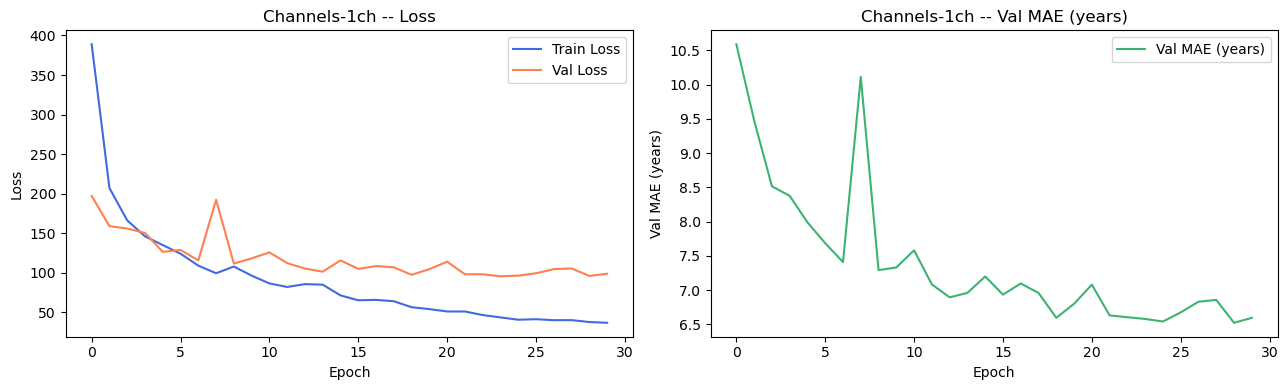


  Channels-3ch  [regression]
  Params: 2,224,129
  Ep   1/30  TrainLoss 421.2744  ValLoss 222.6384  ValMAE 10.6292
  Ep   5/30  TrainLoss 131.9915  ValLoss 123.0604  ValMAE 7.5035
  Ep  10/30  TrainLoss 85.1387  ValLoss 121.1920  ValMAE 7.3790
  Ep  15/30  TrainLoss 70.8219  ValLoss 141.3057  ValMAE 8.3619
  Ep  20/30  TrainLoss 45.6116  ValLoss 93.2689  ValMAE 6.4362
  Ep  25/30  TrainLoss 41.2878  ValLoss 93.0448  ValMAE 6.3654
  Ep  30/30  TrainLoss 36.2401  ValLoss 93.3275  ValMAE 6.4398
  Test MAE: 5.9251


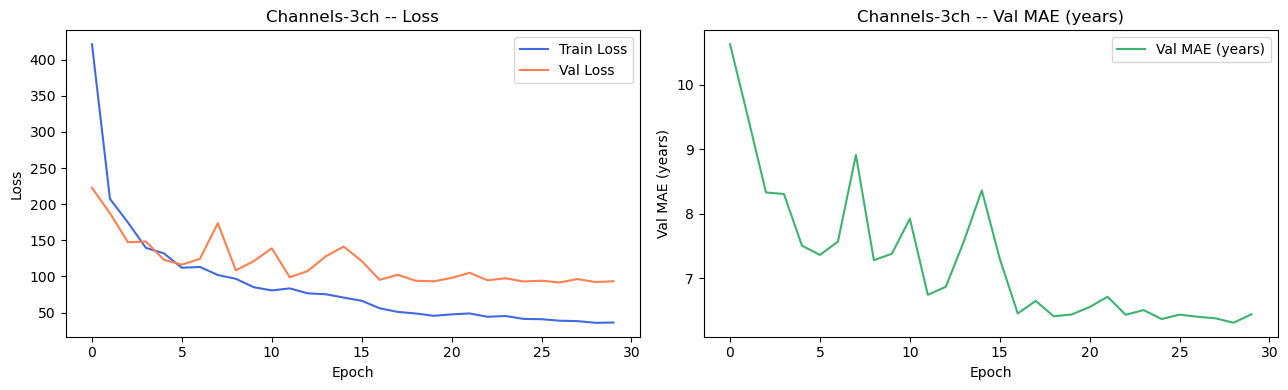

In [19]:
for ch in [1, 3]:
    run_experiment(
        name=f'Channels-{ch}ch',
        model_fn=lambda c=ch: FlexCNN(channels=c, task='regression'),
        task='regression', channels=ch, epochs=30
    )


### 10.2 Data Augmentation


  Augmentation-No  [regression]
  Params: 2,224,129
  Ep   1/30  TrainLoss 415.5033  ValLoss 215.1695  ValMAE 11.0315
  Ep   5/30  TrainLoss 131.9031  ValLoss 126.3760  ValMAE 7.6527
  Ep  10/30  TrainLoss 93.5760  ValLoss 109.6983  ValMAE 7.3071
  Ep  15/30  TrainLoss 74.0465  ValLoss 137.3439  ValMAE 7.8710
  Ep  20/30  TrainLoss 52.0096  ValLoss 94.5141  ValMAE 6.5071
  Ep  25/30  TrainLoss 44.5166  ValLoss 93.6588  ValMAE 6.5455
  Ep  30/30  TrainLoss 42.0647  ValLoss 97.9049  ValMAE 6.5237
  Test MAE: 6.0003


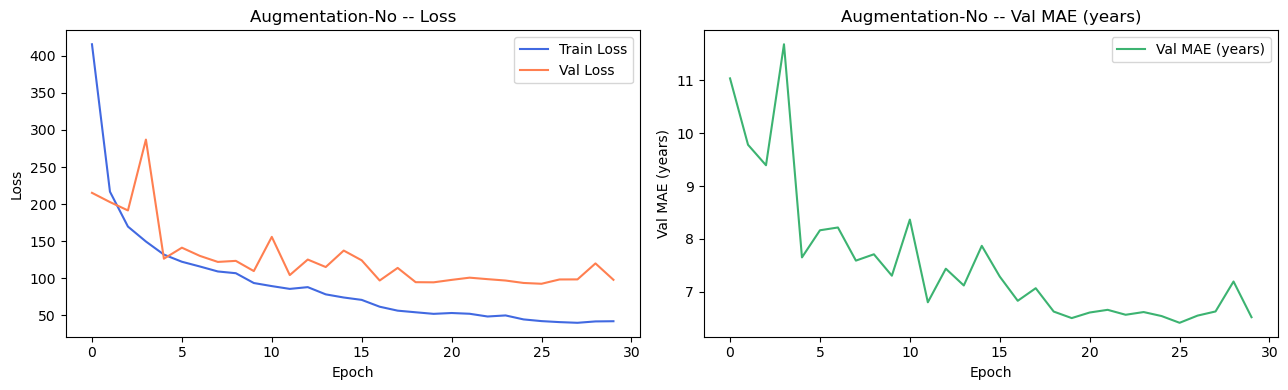


  Augmentation-Yes  [regression]
  Params: 2,224,129
  Ep   1/30  TrainLoss 522.4610  ValLoss 391.1449  ValMAE 13.8565
  Ep   5/30  TrainLoss 201.9471  ValLoss 152.3416  ValMAE 8.4081
  Ep  10/30  TrainLoss 166.8057  ValLoss 182.8369  ValMAE 9.3953
  Ep  15/30  TrainLoss 136.6882  ValLoss 107.3916  ValMAE 7.1283
  Ep  20/30  TrainLoss 137.1289  ValLoss 130.8447  ValMAE 7.9041
  Ep  25/30  TrainLoss 110.5114  ValLoss 96.6323  ValMAE 6.6432
  Ep  30/30  TrainLoss 107.2235  ValLoss 105.9141  ValMAE 6.9498
  Test MAE: 6.0089


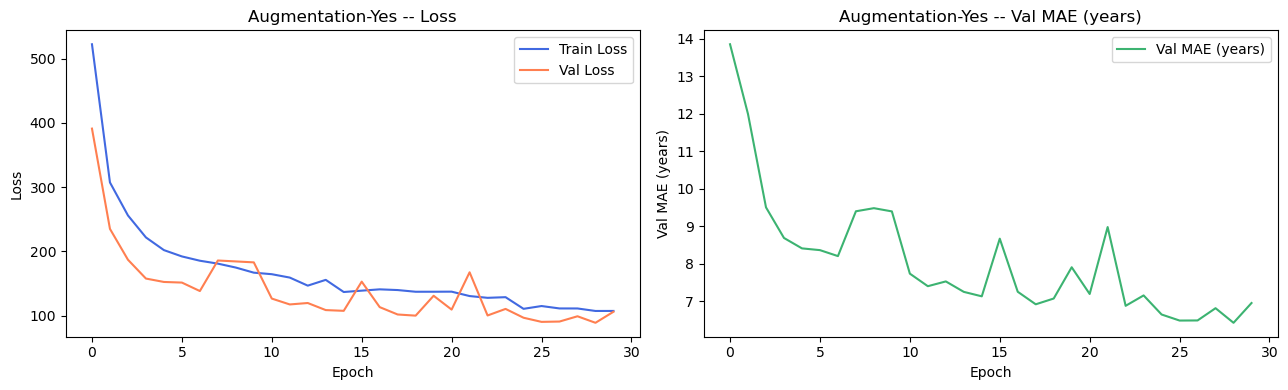

In [20]:
for aug in [False, True]:
    run_experiment(
        name=f'Augmentation-{"Yes" if aug else "No"}',
        model_fn=lambda: FlexCNN(task='regression'),
        task='regression', augment=aug, epochs=30
    )


## 11. Custom Variation — Multi-Scale Feature Fusion CNN

Rationale: fine wrinkles are captured by small (3×3) kernels; broader facial structure
by larger (5×5, 7×7) kernels. Processing all three scales in parallel per block,
then fusing with a 1×1 convolution, lets the network select the most age-relevant
spatial frequencies at each depth.



  MultiScale-Regression  [regression]
  Params: 2,433,804
  Ep   1/30  TrainLoss 448.3409  ValLoss 381.8258  ValMAE 14.1177
  Ep   5/30  TrainLoss 126.0417  ValLoss 134.5520  ValMAE 7.8744
  Ep  10/30  TrainLoss 65.6009  ValLoss 137.2026  ValMAE 8.0998
  Ep  15/30  TrainLoss 39.2261  ValLoss 96.8692  ValMAE 6.4066
  Ep  20/30  TrainLoss 34.0134  ValLoss 97.2523  ValMAE 6.5811
  Ep  25/30  TrainLoss 27.1596  ValLoss 95.4000  ValMAE 6.3395
  Ep  30/30  TrainLoss 25.7442  ValLoss 91.2905  ValMAE 6.2404
  Test MAE: 5.8162


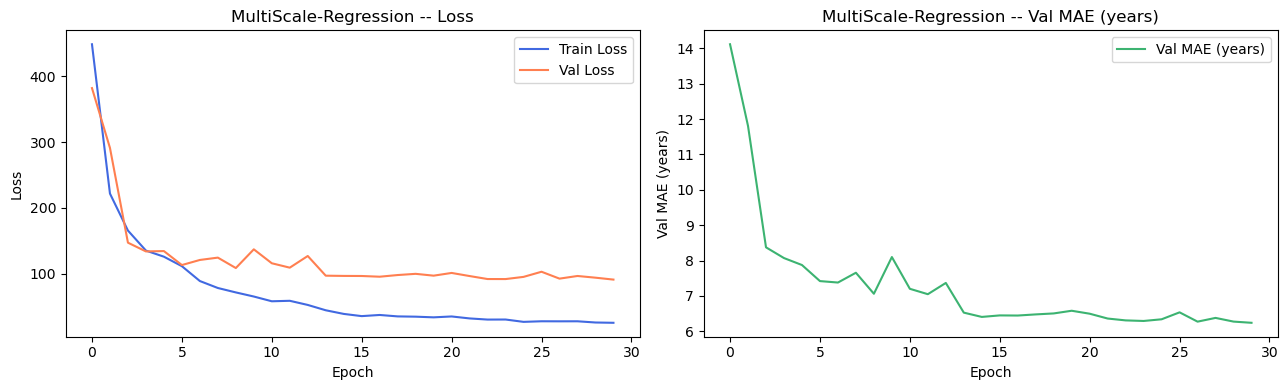


  MultiScale-Classification  [classification]
  Params: 2,434,449
  Ep   1/30  TrainLoss 1.2732  ValLoss 1.0770  ValAcc 0.5430
  Ep   5/30  TrainLoss 0.6987  ValLoss 0.8321  ValAcc 0.6692
  Ep  10/30  TrainLoss 0.3634  ValLoss 0.9132  ValAcc 0.6999
  Ep  15/30  TrainLoss 0.0883  ValLoss 1.2730  ValAcc 0.6999
  Ep  20/30  TrainLoss 0.0302  ValLoss 1.4845  ValAcc 0.7108
  Ep  25/30  TrainLoss 0.0177  ValLoss 1.5818  ValAcc 0.7190
  Early stopping at epoch 29
  Test Acc: 0.6929


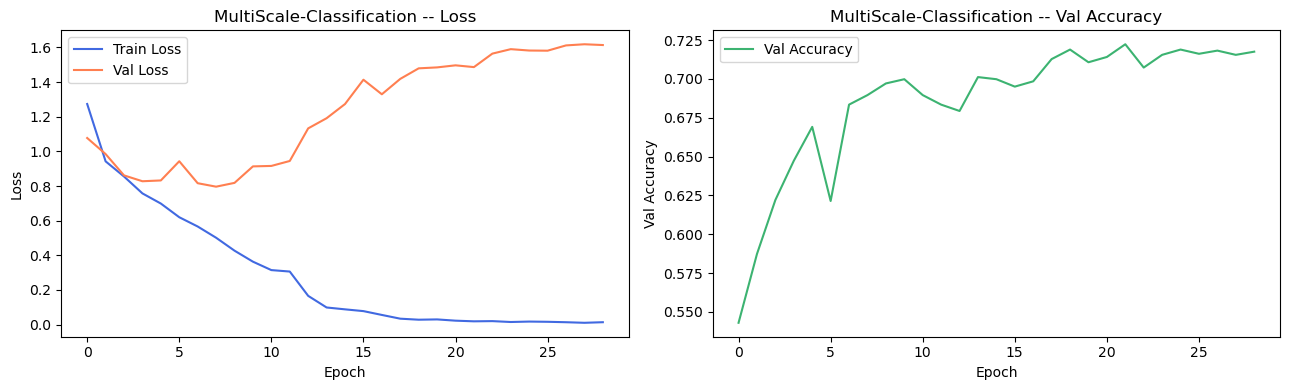

(MultiScaleCNN(
   (features): Sequential(
     (0): MultiScaleBlock(
       (b3): Sequential(
         (0): Conv2d(3, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
         (1): BatchNorm2d(10, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
         (2): ReLU()
       )
       (b5): Sequential(
         (0): Conv2d(3, 10, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
         (1): BatchNorm2d(10, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
         (2): ReLU()
       )
       (b7): Sequential(
         (0): Conv2d(3, 10, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3))
         (1): BatchNorm2d(10, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
         (2): ReLU()
       )
       (merge): Conv2d(30, 32, kernel_size=(1, 1), stride=(1, 1))
       (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
     )
     (1): MultiScaleBlock(
       (b3): Sequential(
         (0): Conv2d(32, 21, ke

In [21]:
run_experiment('MultiScale-Regression',     lambda: MultiScaleCNN(depth=3, task='regression'),     task='regression',     epochs=30)
run_experiment('MultiScale-Classification', lambda: MultiScaleCNN(depth=3, task='classification'), task='classification', epochs=30)


## 12. Classification Task
### 12.1 Raw Logits vs Explicit Softmax


  Cls-RawLogits  [classification]
  Params: 2,224,774
  Ep   1/30  TrainLoss 1.4489  ValLoss 1.1605  ValAcc 0.5095
  Ep   5/30  TrainLoss 0.8902  ValLoss 0.8502  ValAcc 0.6419
  Ep  10/30  TrainLoss 0.7098  ValLoss 0.7837  ValAcc 0.6671
  Ep  15/30  TrainLoss 0.5085  ValLoss 0.7472  ValAcc 0.7019
  Ep  20/30  TrainLoss 0.3517  ValLoss 0.7998  ValAcc 0.7012
  Early stopping at epoch 22
  Test Acc: 0.7011


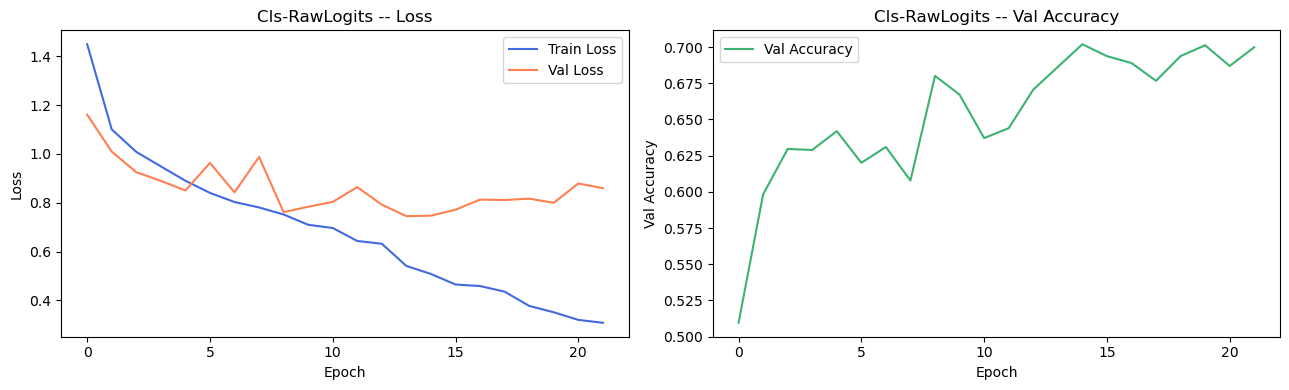


  Cls-WithSoftmax  [classification]
  Params: 2,224,774
  Ep   1/30  TrainLoss 1.7084  ValLoss 1.7237  ValAcc 0.3199
  Ep   5/30  TrainLoss 1.6341  ValLoss 1.6081  ValAcc 0.4256
  Ep  10/30  TrainLoss 1.4447  ValLoss 1.4424  ValAcc 0.5948
  Ep  15/30  TrainLoss 1.3997  ValLoss 1.4258  ValAcc 0.6160
  Ep  20/30  TrainLoss 1.3643  ValLoss 1.4019  ValAcc 0.6385
  Ep  25/30  TrainLoss 1.3253  ValLoss 1.3867  ValAcc 0.6528
  Ep  30/30  TrainLoss 1.3024  ValLoss 1.3888  ValAcc 0.6460
  Test Acc: 0.6510


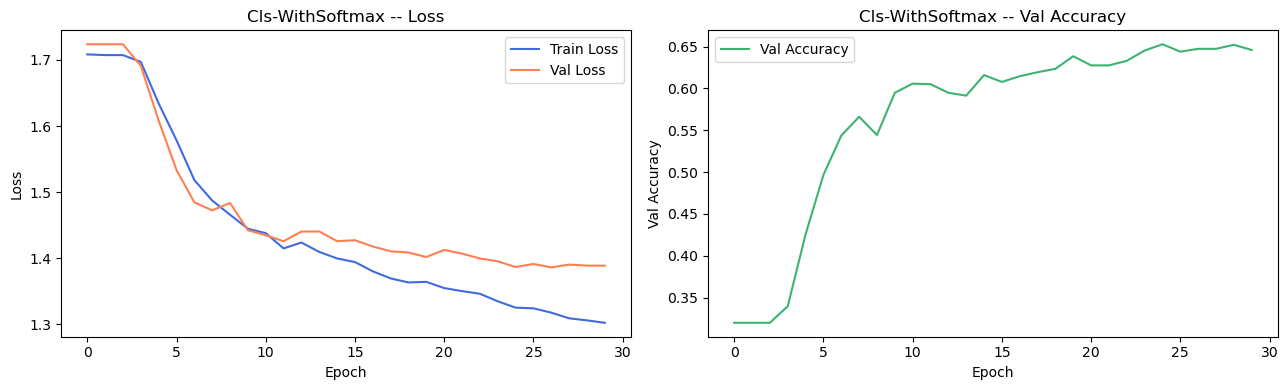

(FlexCNN_Softmax(
   (features): Sequential(
     (0): ConvBlock(
       (block): Sequential(
         (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
         (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
         (2): ReLU()
         (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
       )
     )
     (1): ConvBlock(
       (block): Sequential(
         (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
         (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
         (2): ReLU()
         (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
       )
     )
     (2): ConvBlock(
       (block): Sequential(
         (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
         (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
         (2): ReLU()
         (3)

In [22]:
run_experiment('Cls-RawLogits',   lambda: FlexCNN(depth=3,         task='classification'), task='classification', epochs=30)
run_experiment('Cls-WithSoftmax', lambda: FlexCNN_Softmax(depth=3, task='classification'), task='classification', epochs=30)


### 12.2 Skip Connections for Classification


  Cls-ResCNN  [classification]
  Params: 2,429,542
  Ep   1/30  TrainLoss 1.4810  ValLoss 1.1815  ValAcc 0.5464
  Ep   5/30  TrainLoss 0.7834  ValLoss 0.8439  ValAcc 0.6330
  Ep  10/30  TrainLoss 0.4704  ValLoss 0.8082  ValAcc 0.6944
  Ep  15/30  TrainLoss 0.1683  ValLoss 1.1503  ValAcc 0.7060
  Ep  20/30  TrainLoss 0.0769  ValLoss 1.3889  ValAcc 0.7033
  Early stopping at epoch 21
  Test Acc: 0.7032


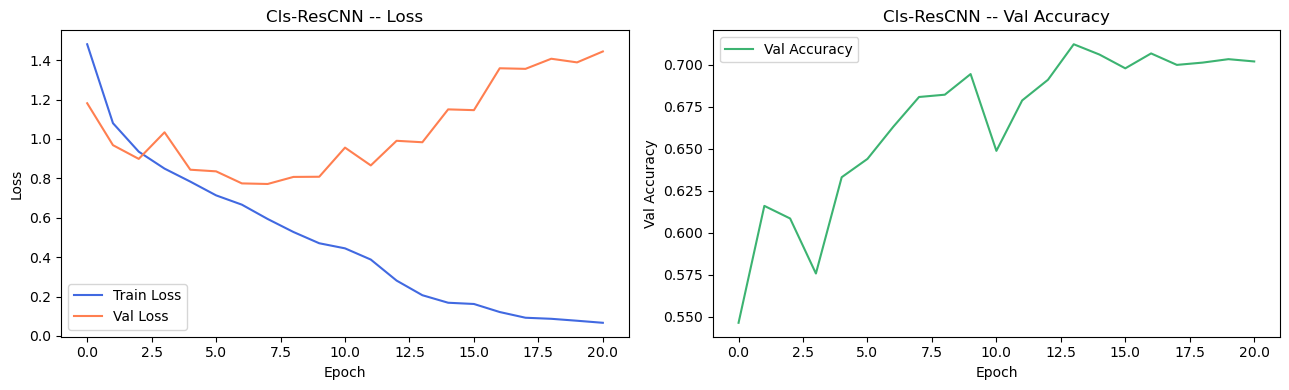

(ResCNN(
   (features): Sequential(
     (0): ResBlock(
       (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
       (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
       (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
       (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
       (act): ReLU()
       (proj): Conv2d(3, 32, kernel_size=(1, 1), stride=(1, 1))
       (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
     )
     (1): ResBlock(
       (conv1): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
       (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
       (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
       (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
       (act): ReLU()
       (proj): Con

In [23]:
run_experiment('Cls-ResCNN', lambda: ResCNN(depth=3, task='classification'), task='classification', epochs=30)


### 12.3 Augmentation for Classification


  Cls-Augmented  [classification]
  Params: 2,224,774
  Ep   1/30  TrainLoss 1.6048  ValLoss 1.3044  ValAcc 0.4829
  Ep   5/30  TrainLoss 1.0339  ValLoss 0.9323  ValAcc 0.6248
  Ep  10/30  TrainLoss 0.9232  ValLoss 0.8567  ValAcc 0.6467
  Ep  15/30  TrainLoss 0.8501  ValLoss 0.8023  ValAcc 0.6658
  Ep  20/30  TrainLoss 0.7945  ValLoss 0.7654  ValAcc 0.6883
  Ep  25/30  TrainLoss 0.7668  ValLoss 0.7551  ValAcc 0.6917
  Ep  30/30  TrainLoss 0.7246  ValLoss 0.7680  ValAcc 0.6801
  Test Acc: 0.7103


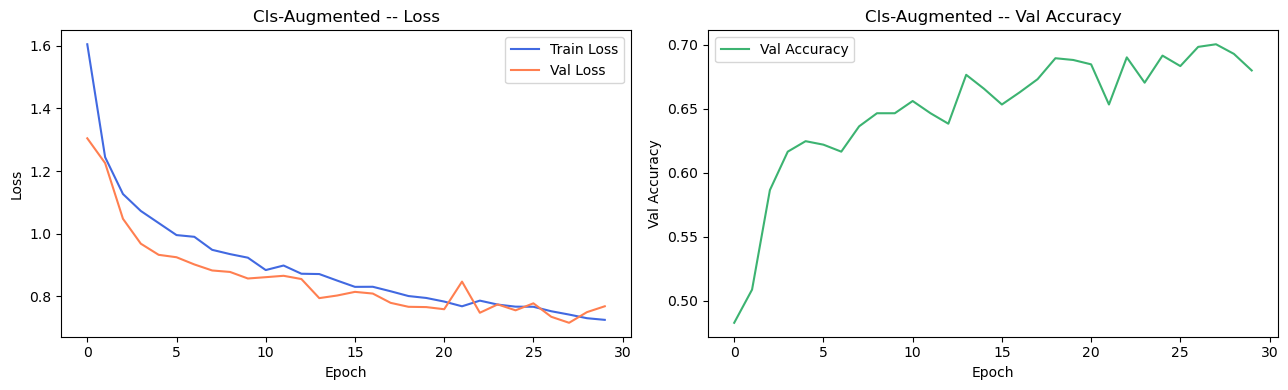

(FlexCNN(
   (features): Sequential(
     (0): ConvBlock(
       (block): Sequential(
         (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
         (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
         (2): ReLU()
         (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
       )
     )
     (1): ConvBlock(
       (block): Sequential(
         (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
         (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
         (2): ReLU()
         (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
       )
     )
     (2): ConvBlock(
       (block): Sequential(
         (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
         (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
         (2): ReLU()
         (3): MaxPoo

In [24]:
run_experiment('Cls-Augmented', lambda: FlexCNN(depth=3, task='classification'), task='classification', augment=True, epochs=30)


## 13. Results Summary

In [25]:
rows = [dict(Experiment=r['name'], Task=r['task'], Channels=r['channels'],
             Augmented=r['augment'],
             BestVal=round(r['best_val'], 4),
             TestMetric=round(r['test_metric'], 4),
             Metric=r['metric_name'])
        for r in RESULTS]

summary_df = pd.DataFrame(rows)
summary_df.to_csv('results_summary.csv', index=False)

print('=== Regression (lower MAE is better) ===')
reg = summary_df[summary_df['Task']=='regression'].sort_values('TestMetric')
print(reg[['Experiment','Channels','Augmented','BestVal','TestMetric']].to_string(index=False))

print('\n=== Classification (higher Acc is better) ===')
cls = summary_df[summary_df['Task']=='classification'].sort_values('TestMetric', ascending=False)
print(cls[['Experiment','Channels','Augmented','BestVal','TestMetric']].to_string(index=False))


=== Regression (lower MAE is better) ===
           Experiment  Channels  Augmented  BestVal  TestMetric
              Depth-5         3      False   6.0452      5.4849
 Activation-LeakyReLU         3      False   6.0266      5.7061
       FC-2FC-256-128         3      False   6.3704      5.8015
      Activation-SELU         3      False   6.2488      5.8156
MultiScale-Regression         3      False   6.2404      5.8162
           Kernel-7x7         3      False   6.3176      5.8183
              Depth-4         3      False   6.2322      5.8548
           Kernel-5x5         3      False   6.3383      5.8894
           Kernel-3x3         3      False   6.5154      5.9043
         Channels-3ch         3      False   6.3069      5.9251
       NoSkip-FlexCNN         3      False   6.6797      5.9601
      WithSkip-ResCNN         3      False   6.0412      5.9648
      Activation-ReLU         3      False   6.5133      5.9666
   FC-3FC-512-256-128         3      False   6.3888      5.9744

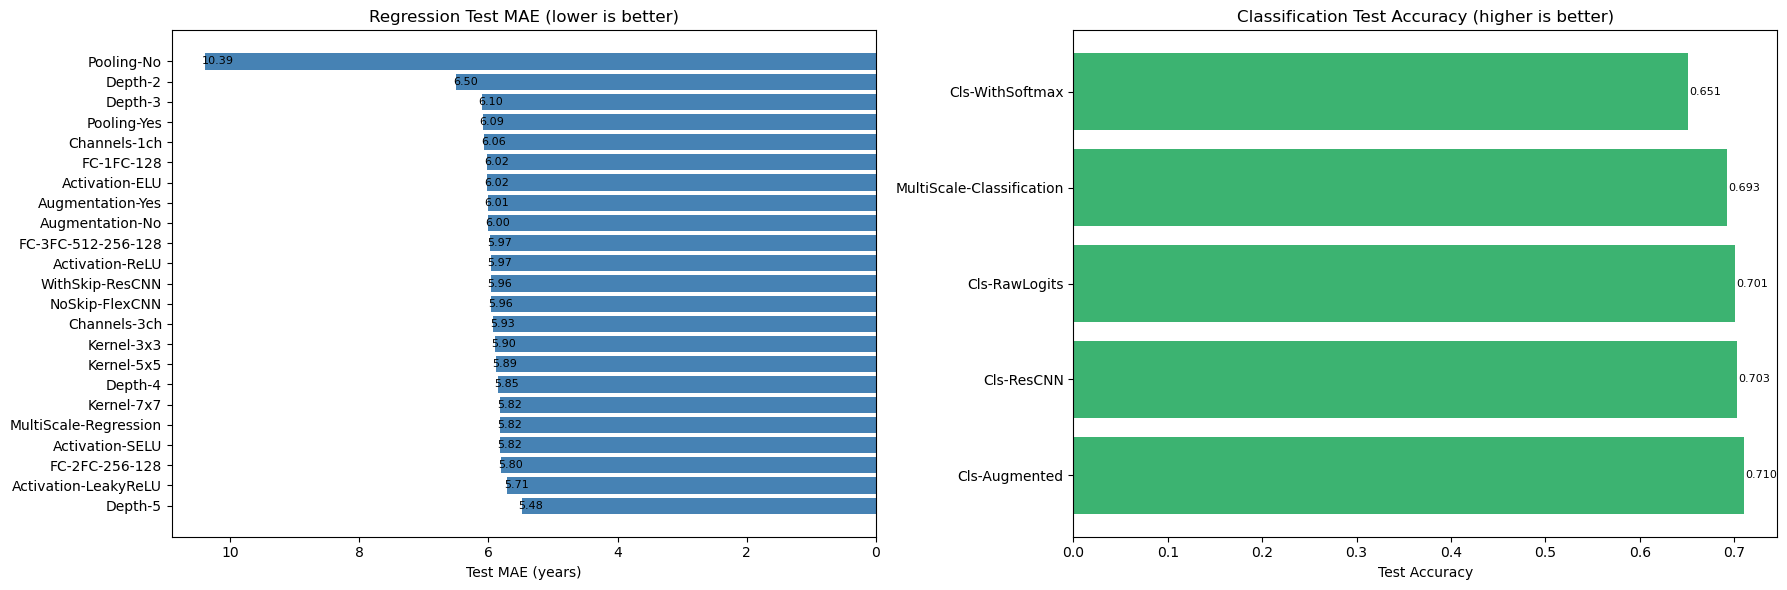

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

ax = axes[0]
bars = ax.barh(reg['Experiment'], reg['TestMetric'], color='steelblue')
ax.set_xlabel('Test MAE (years)')
ax.set_title('Regression Test MAE (lower is better)')
ax.invert_xaxis()
for bar, val in zip(bars, reg['TestMetric']):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center', fontsize=8)

ax = axes[1]
bars = ax.barh(cls['Experiment'], cls['TestMetric'], color='mediumseagreen')
ax.set_xlabel('Test Accuracy')
ax.set_title('Classification Test Accuracy (higher is better)')
for bar, val in zip(bars, cls['TestMetric']):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('results_comparison.png', dpi=120, bbox_inches='tight')
plt.show()


## 14. Save the Two Best Models

Models are saved to `saved_models/` in the same folder as this notebook.  
They persist on disk — no Drive mounting needed.  
To back them up, simply copy the `saved_models/` folder to wherever you want.


In [27]:
os.makedirs('saved_models', exist_ok=True)

best_reg = sorted([r for r in RESULTS if r['task']=='regression'],
                  key=lambda x: x['test_metric'])[0]
best_cls = sorted([r for r in RESULTS if r['task']=='classification'],
                  key=lambda x: x['test_metric'], reverse=True)[0]

for result, fname in [(best_reg, 'saved_models/best_regression.pth'),
                      (best_cls, 'saved_models/best_classification.pth')]:
    torch.save({
        'model_state_dict': result['model'].state_dict(),
        'model_class':      type(result['model']).__name__,
        'experiment_name':  result['name'],
        'task':             result['task'],
        'channels':         result['channels'],
        'test_metric':      result['test_metric'],
        'metric_name':      result['metric_name'],
        'num_classes':      NUM_CLASSES,
        'categories':       CATEGORIES,
    }, fname)
    print(f'Saved : {fname}')
    print(f'  Model      : {type(result["model"]).__name__}')
    print(f'  Experiment : {result["name"]}')
    print(f'  Test {result["metric_name"]:10s}: {result["test_metric"]:.4f}')


Saved : saved_models/best_regression.pth
  Model      : FlexCNN
  Experiment : Depth-5
  Test MAE       : 5.4849
Saved : saved_models/best_classification.pth
  Model      : FlexCNN
  Experiment : Cls-Augmented
  Test Acc       : 0.7103


## 15. Demo — Load Saved Models and Evaluate on Held-Out Test Set

In [30]:
def load_saved_model(path):
    ckpt = torch.load(path, map_location=DEVICE, weights_only=False)

    # Reconstruct depth from the saved state_dict by counting feature blocks
    state_keys  = ckpt['model_state_dict'].keys()
    block_idxs  = [int(k.split('.')[1]) for k in state_keys if k.startswith('features.')]
    depth       = max(block_idxs) + 1 if block_idxs else 3
    print(f'  Detected depth: {depth}')

    model_cls = MODEL_REGISTRY[ckpt['model_class']]
    model     = model_cls(depth=depth, task=ckpt['task'], channels=ckpt['channels'])
    model.load_state_dict(ckpt['model_state_dict'])
    model     = model.to(DEVICE).eval()
    print(f'Loaded {ckpt["model_class"]} ({ckpt["task"]}) -- '
          f'saved Test {ckpt["metric_name"]}: {ckpt["test_metric"]:.4f}')
    return model, ckpt

reg_model, reg_ckpt = load_saved_model('saved_models/best_regression.pth')
cls_model, cls_ckpt = load_saved_model('saved_models/best_classification.pth')

  Detected depth: 5
Loaded FlexCNN (regression) -- saved Test MAE: 5.4849
  Detected depth: 3
Loaded FlexCNN (classification) -- saved Test Acc: 0.7103


In [31]:
_, eval_tf3 = get_transforms(channels=3)
_, eval_tf1 = get_transforms(channels=1)

def demo_eval(model, ckpt):
    tf      = eval_tf3 if ckpt['channels'] == 3 else eval_tf1
    ds      = FaceAgeDataset('data/test.csv', transform=tf, channels=ckpt['channels'])
    loader  = DataLoader(ds, batch_size=64, shuffle=False,
                         num_workers=NUM_WORKERS, pin_memory=(DEVICE.type=='cuda'))
    loss_fn = nn.MSELoss() if ckpt['task'] == 'regression' else nn.CrossEntropyLoss()
    _, metric = evaluate(model, loader, loss_fn, ckpt['task'])
    print(f'  Test {ckpt["metric_name"]}: {metric:.4f}')
    return metric

print('--- Best Regression Model ---')
demo_eval(reg_model, reg_ckpt)
print('\n--- Best Classification Model ---')
demo_eval(cls_model, cls_ckpt)


--- Best Regression Model ---
  Test MAE: 5.4849

--- Best Classification Model ---
  Test Acc: 0.7103


0.7103377686796315

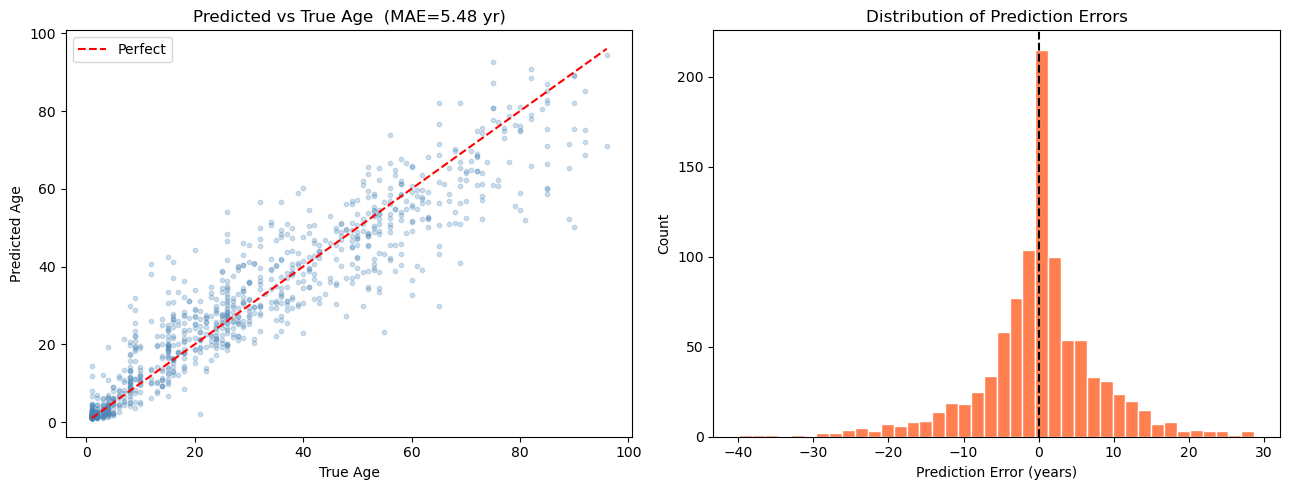

In [32]:
@torch.no_grad()
def get_reg_preds(model, ckpt):
    tf     = eval_tf3 if ckpt['channels'] == 3 else eval_tf1
    ds     = FaceAgeDataset('data/test.csv', transform=tf, channels=ckpt['channels'])
    loader = DataLoader(ds, batch_size=64, shuffle=False, num_workers=NUM_WORKERS)
    model.eval()
    preds, trues = [], []
    for imgs, ages, _ in loader:
        out = model(imgs.to(DEVICE)).squeeze(1)
        preds.extend(out.cpu().numpy())
        trues.extend(ages.numpy())
    return np.array(trues), np.array(preds)

trues, preds = get_reg_preds(reg_model, reg_ckpt)
mae = mean_absolute_error(trues, preds)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
ax1.scatter(trues, preds, alpha=0.25, s=10, color='steelblue')
lo, hi = trues.min(), trues.max()
ax1.plot([lo, hi], [lo, hi], 'r--', label='Perfect')
ax1.set_xlabel('True Age'); ax1.set_ylabel('Predicted Age')
ax1.set_title(f'Predicted vs True Age  (MAE={mae:.2f} yr)')
ax1.legend()

errors = preds - trues
ax2.hist(errors, bins=40, color='coral', edgecolor='white')
ax2.axvline(0, color='black', linestyle='--')
ax2.set_xlabel('Prediction Error (years)'); ax2.set_ylabel('Count')
ax2.set_title('Distribution of Prediction Errors')
plt.tight_layout()
plt.savefig('demo_regression.png', dpi=120, bbox_inches='tight')
plt.show()


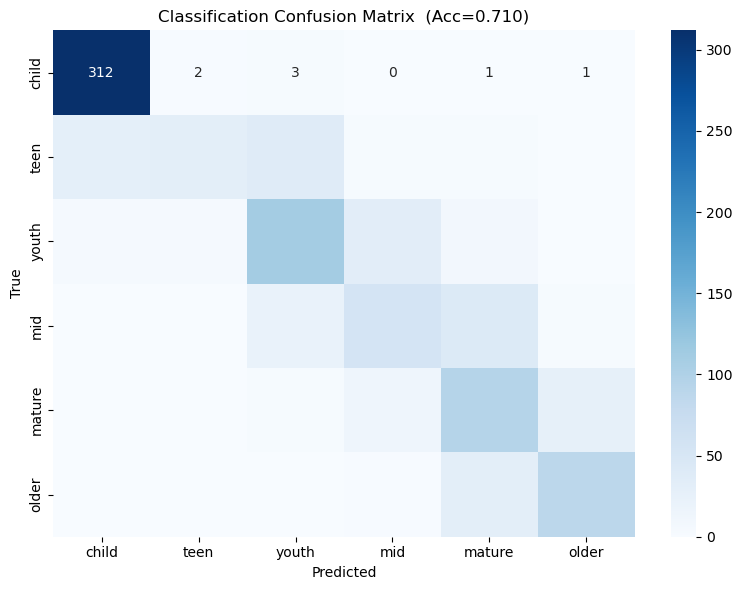

              precision    recall  f1-score   support

       child       0.90      0.98      0.94       319
        teen       0.82      0.30      0.44       106
       youth       0.63      0.67      0.65       166
         mid       0.51      0.45      0.48       124
      mature       0.52      0.67      0.59       140
       older       0.73      0.72      0.72       122

    accuracy                           0.71       977
   macro avg       0.68      0.63      0.64       977
weighted avg       0.72      0.71      0.70       977



In [33]:
@torch.no_grad()
def get_cls_preds(model, ckpt):
    tf     = eval_tf3 if ckpt['channels'] == 3 else eval_tf1
    ds     = FaceAgeDataset('data/test.csv', transform=tf, channels=ckpt['channels'])
    loader = DataLoader(ds, batch_size=64, shuffle=False, num_workers=NUM_WORKERS)
    model.eval()
    preds, trues = [], []
    for imgs, _, cats in loader:
        preds.extend(model(imgs.to(DEVICE)).argmax(1).cpu().numpy())
        trues.extend(cats.numpy())
    return np.array(trues), np.array(preds)

trues_c, preds_c = get_cls_preds(cls_model, cls_ckpt)
acc = np.mean(trues_c == preds_c)

cm = confusion_matrix(trues_c, preds_c)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CAT_NAMES, yticklabels=CAT_NAMES, ax=ax)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title(f'Classification Confusion Matrix  (Acc={acc:.3f})')
plt.tight_layout()
plt.savefig('demo_classification_cm.png', dpi=120, bbox_inches='tight')
plt.show()
print(classification_report(trues_c, preds_c, target_names=CAT_NAMES))


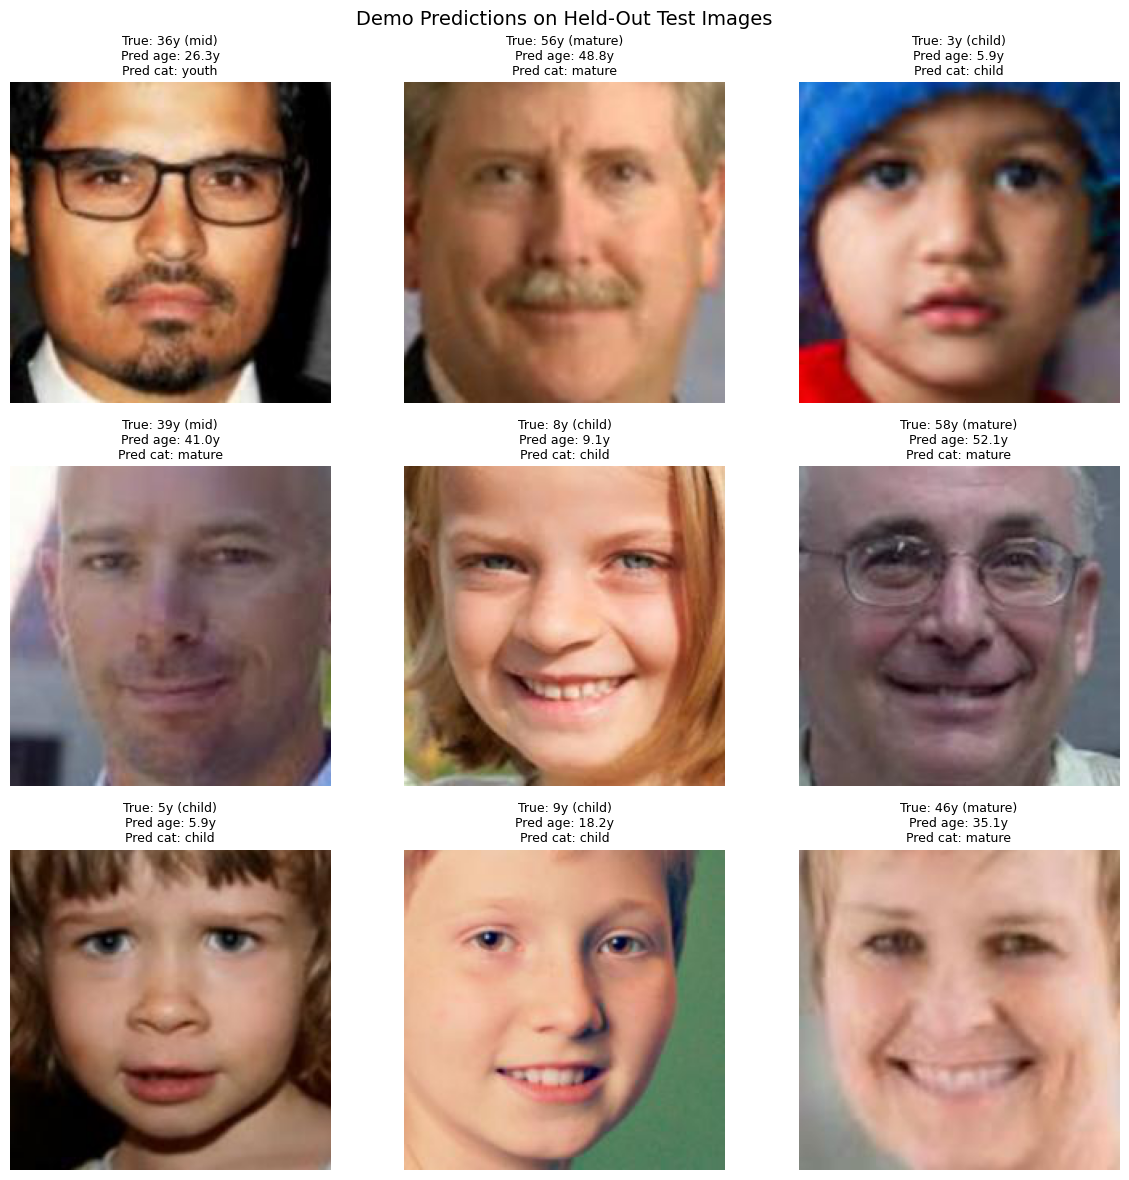

In [34]:
test_df = pd.read_csv('data/test.csv')
sample  = test_df.sample(9, random_state=42)

fig, axes = plt.subplots(3, 3, figsize=(12, 12))
reg_model.eval(); cls_model.eval()

for ax, (_, row) in zip(axes.flat, sample.iterrows()):
    img_pil = Image.open(row['path']).convert('RGB')
    ax.imshow(img_pil)
    inp = eval_tf3(img_pil).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        pred_age = reg_model(inp).item() if reg_ckpt['channels'] == 3 else None
        cat_pred = cls_model(inp).argmax(1).item() if cls_ckpt['channels'] == 3 else None
    lines = [f'True: {int(row["age"])}y ({row["category_name"]})']
    if pred_age is not None: lines.append(f'Pred age: {pred_age:.1f}y')
    if cat_pred is not None: lines.append(f'Pred cat: {CAT_NAMES[cat_pred]}')
    ax.set_title('\n'.join(lines), fontsize=9)
    ax.axis('off')

plt.suptitle('Demo Predictions on Held-Out Test Images', fontsize=14)
plt.tight_layout()
plt.savefig('demo_sample_predictions.png', dpi=120, bbox_inches='tight')
plt.show()


## 16. Final Summary

In [35]:
print('=' * 60)
print('  FINAL SUMMARY')
print('=' * 60)
print(f'Best REGRESSION model : {reg_ckpt["experiment_name"]}')
print(f'  Test MAE            : {reg_ckpt["test_metric"]:.2f} years')
print()
print(f'Best CLASSIFICATION model : {cls_ckpt["experiment_name"]}')
print(f'  Test Accuracy           : {cls_ckpt["test_metric"]:.4f}')
print('\nSaved outputs:')
for f in ['age_distribution.png','sample_faces.png','category_balance.png',
          'results_summary.csv','results_comparison.png',
          'demo_regression.png','demo_classification_cm.png',
          'demo_sample_predictions.png',
          'saved_models/best_regression.pth',
          'saved_models/best_classification.pth']:
    status = 'OK' if os.path.exists(f) else 'MISSING'
    print(f'  [{status}]  {f}')


  FINAL SUMMARY
Best REGRESSION model : Depth-5
  Test MAE            : 5.48 years

Best CLASSIFICATION model : Cls-Augmented
  Test Accuracy           : 0.7103

Saved outputs:
  [OK]  age_distribution.png
  [OK]  sample_faces.png
  [OK]  category_balance.png
  [OK]  results_summary.csv
  [OK]  results_comparison.png
  [OK]  demo_regression.png
  [OK]  demo_classification_cm.png
  [OK]  demo_sample_predictions.png
  [OK]  saved_models/best_regression.pth
  [OK]  saved_models/best_classification.pth
